# Arizona Case Study — Stochastic Post-Processing (SI Units)

Post-processes the Monte Carlo output produced by `Arizona_Case_Study_Stochastic.ipynb` (CSV/Parquet files under `Correlation_0.0001/`, `Correlation_0.15/`, `Sensitivity/`, and `segment_results/`). All results are stored by the source notebook in US customary units; this notebook converts them to SI units (IRI in m/km, rutting in mm) and inflation-adjusts user cost to 2025 dollars before producing the correlation, reliability, and sensitivity figures used in the manuscript.

Requires `Arizona_Case_Study_Stochastic.ipynb` to have been run first, with its outputs present in this same folder.


## Correlation


## Scenario 1 – Cost Uncertainty (COV_IRI = 0.0001)

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Constants
# ============================================================
sns.set_theme(style="whitegrid", font_scale=1.6, rc={"axes.edgecolor": "black", "axes.linewidth": 1.2, "grid.color": "0.85"})

BASE_PATH = pathlib.Path("Correlation_0.0001")
COV_TAG   = "_cov0.0001"

PERCENTILE_BAND      = (25, 75)
FIGSIZE              = (22, 7)
# SI unit conversion: IRI is stored in in/mi (US customary); 1 in/mi = 0.0157828 m/km.
IRI_IN_MI_TO_M_KM    = 0.0157828
# Rutting is stored in inches (US customary); 1 in = 25.4 mm.
RUTTING_IN_TO_MM     = 25.4
# CPI-U All Items, U.S. city average, annual average: convert user cost from
# 2024 dollars (simulation basis) to 2025 dollars. CPI 2024 = 313.689, CPI 2025 = 321.943.
CPI_2024 = 313.689
CPI_2025 = 321.943
CPI_ADJUSTMENT_2025 = CPI_2025 / CPI_2024
# Figure size used only for the single-budget strategy-comparison and the
# multi-budget per-strategy line plots, matched to the prior presentation
# (TRL.ipynb) so slides are the same size/font for easy audience comparison.
PRESENTATION_FIGSIZE = (12, 7)
LINEWIDTH            = 3
MARKERSIZE           = 12
BAND_ALPHA           = 0.20

palette = sns.color_palette("deep")

STRATEGY_STYLES = {
    "Strategy 1": {
        "color": palette[0], "marker": "o", "linestyle": "-", "label": "Strategy 1",
    },
    "Strategy 2": {
        "color": palette[1], "marker": "X", "linestyle": "--", "label": "Strategy 2",
    },
    "Strategy 3": {
        "color": "green", "marker": "s", "linestyle": "-.", "label": "Strategy 3",
    },
}

# seaborn's dashes= parameter needs numeric dash-length tuples, not linestyle strings
LINESTYLE_TO_DASHES = {"-": "", "--": (4, 1.5), "-.": (3, 1, 1, 1), ":": (1, 1)}

MULTI_BUDGET_MARKERS = ["o", "X", "s", "D", "^", "v", "P", "*"]

# ------------------------------------------------------------------
# Print/B&W-friendly panel labels: red (a), (b), (c)... in each subplot's
# upper-left corner, matching the reference-figure convention.
# ------------------------------------------------------------------
def add_panel_labels(axes, fontsize=18):
    import string
    for i, ax in enumerate(np.ravel(axes)):
        ax.text(0.03, 0.95, f"({string.ascii_lowercase[i]})", transform=ax.transAxes,
                 color="red", fontsize=fontsize, fontweight="bold", va="top", ha="left")

# ============================================================
# Load CSVs
# ============================================================
worst_single    = pd.read_csv(BASE_PATH / f"single_budget_simulation_worstfirst{COV_TAG}.csv")
benefit_single  = pd.read_csv(BASE_PATH / f"single_budget_simulation_benefit{COV_TAG}.csv")
benefitA_single = pd.read_csv(BASE_PATH / f"single_budget_simulation_benefit_aadt{COV_TAG}.csv")

worst_multi     = pd.read_csv(BASE_PATH / f"multi_budget_simulation_results_worstfirst{COV_TAG}.csv")
benefit_multi   = pd.read_csv(BASE_PATH / f"multi_budget_simulation_results_benefit{COV_TAG}.csv")
benefitA_multi  = pd.read_csv(BASE_PATH / f"multi_budget_simulation_results_benefit_aadt{COV_TAG}.csv")

for _df in (worst_single, benefit_single, benefitA_single, worst_multi, benefit_multi, benefitA_multi):
    _df["weighted_avg_iri"] *= IRI_IN_MI_TO_M_KM
    _df["weighted_avg_rutting"] *= RUTTING_IN_TO_MM
    _df["user_cost"] *= CPI_ADJUSTMENT_2025

FINAL_YEAR = int(worst_single["year"].max())

print("Columns :", worst_single.columns.tolist())
print("Single shapes — Strategy 1:", worst_single.shape, "| Strategy 2:", benefit_single.shape,
      "| Strategy 3:", benefitA_single.shape)
print("FINAL_YEAR :", FINAL_YEAR)

# ============================================================
# Helper: summarise metric by year (median + p25/p75)
# ============================================================
def summarize_by_year(df, value_col):
    lo, hi = PERCENTILE_BAND
    return (
        df.groupby("year", sort=True)[value_col]
        .agg(median="median",
             p10=lambda x: np.percentile(x, lo),
             p90=lambda x: np.percentile(x, hi))
        .reset_index()
        .sort_values("year")
    )


def format_budget_label(budget):
    return f"${int(budget / 1e6)}M"

# ============================================================
# Single-budget strategy comparison plot
# ============================================================
def plot_strategy_comparison(strategy_frames, value_col, ylabel, y_limits=(None, None), label_map=None):
    """hue=strategy drives color/marker/legend; seaborn computes the median
    line and P25-P75 band directly from raw per-simulation rows."""
    label_map = label_map or {}
    disp = {name: label_map.get(name, STRATEGY_STYLES[name]["label"]) for name in strategy_frames}
    long_df = pd.concat(
        [df.assign(strategy=disp[name]) for name, df in strategy_frames.items()],
        ignore_index=True,
    )
    hue_order = list(disp.values())
    pal     = {disp[name]: STRATEGY_STYLES[name]["color"] for name in strategy_frames}
    markers = {disp[name]: STRATEGY_STYLES[name]["marker"] for name in strategy_frames}
    dashes  = {disp[name]: LINESTYLE_TO_DASHES[STRATEGY_STYLES[name]["linestyle"]] for name in strategy_frames}

    fig, ax = plt.subplots(figsize=PRESENTATION_FIGSIZE)
    sns.lineplot(data=long_df, x="year", y=value_col, hue="strategy", style="strategy",
                 hue_order=hue_order, style_order=hue_order,
                 palette=pal, markers=markers, dashes=dashes,
                 estimator="median", errorbar=("pi", PERCENTILE_BAND[1] - PERCENTILE_BAND[0]),
                 err_kws={"alpha": BAND_ALPHA},
                 linewidth=LINEWIDTH, markersize=MARKERSIZE, ax=ax)
    ax.set_xlabel("Year", fontsize=20, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=20, fontweight="bold")
    ax.set_xticks(sorted(long_df["year"].unique()))
    ax.tick_params(labelsize=18)
    y_min, y_max = y_limits
    if y_min is not None and y_max is not None:
        ax.set_ylim(y_min, y_max)
    ax.legend(title="Strategy", fontsize=20, title_fontsize=20, loc="upper left")
    plt.tight_layout()
    plt.show()

# ============================================================
# Multi-budget line plot (one line per budget level)
# ============================================================
def plot_metric_by_budget(df, metric_col, y_label, y_min=None, y_max=None, legend_title="Budget Level"):
    """hue=budget drives color/marker/legend; seaborn computes the median
    line and P25-P75 band directly from raw per-simulation rows."""
    budgets       = sorted(df["budget"].unique())
    budget_labels = [format_budget_label(b) for b in budgets]
    plot_df = df.assign(budget_label=df["budget"].map(format_budget_label))
    pal     = {format_budget_label(b): palette[i % len(palette)] for i, b in enumerate(budgets)}
    markers = {format_budget_label(b): MULTI_BUDGET_MARKERS[i % len(MULTI_BUDGET_MARKERS)] for i, b in enumerate(budgets)}

    fig, ax = plt.subplots(figsize=PRESENTATION_FIGSIZE)
    sns.lineplot(data=plot_df, x="year", y=metric_col, hue="budget_label", style="budget_label",
                 hue_order=budget_labels, style_order=budget_labels,
                 palette=pal, markers=markers, dashes=False,
                 estimator="median", errorbar=("pi", PERCENTILE_BAND[1] - PERCENTILE_BAND[0]),
                 err_kws={"alpha": BAND_ALPHA},
                 linewidth=LINEWIDTH, markersize=MARKERSIZE, ax=ax)
    ax.set_xlabel("Year", fontsize=20, fontweight="bold")
    ax.set_ylabel(y_label, fontsize=20, fontweight="bold")
    ax.set_xticks(sorted(df["year"].unique()))
    ax.tick_params(labelsize=18)
    if y_min is not None and y_max is not None:
        ax.set_ylim(y_min, y_max)
    ax.legend(title=legend_title, fontsize=15, title_fontsize=20)
    plt.tight_layout()
    plt.show()

print("Setup complete – CSVs loaded and all helpers defined.")

Columns : ['simulation', 'year', 'weighted_avg_iri', 'weighted_avg_rutting', 'weighted_avg_cracking', 'weighted_avg_composite', 'user_cost']
Single shapes — Strategy 1: (4000, 7) | Strategy 2: (4000, 7) | Strategy 3: (4000, 7)
FINAL_YEAR : 10
Setup complete – CSVs loaded and all helpers defined.


## Single budget

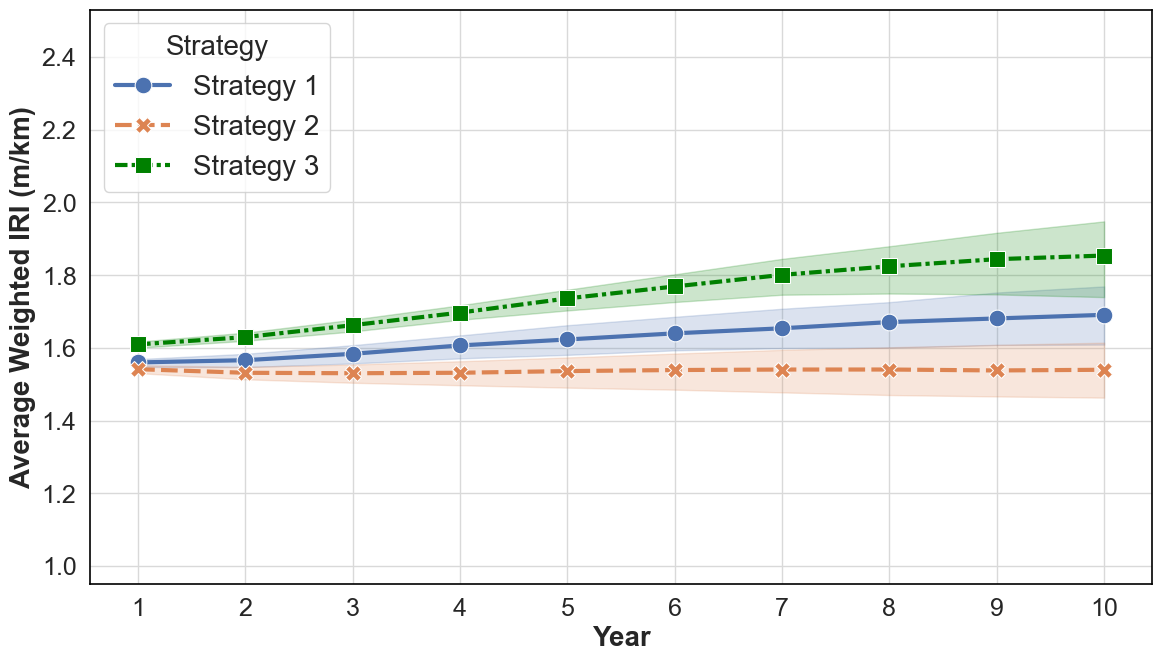

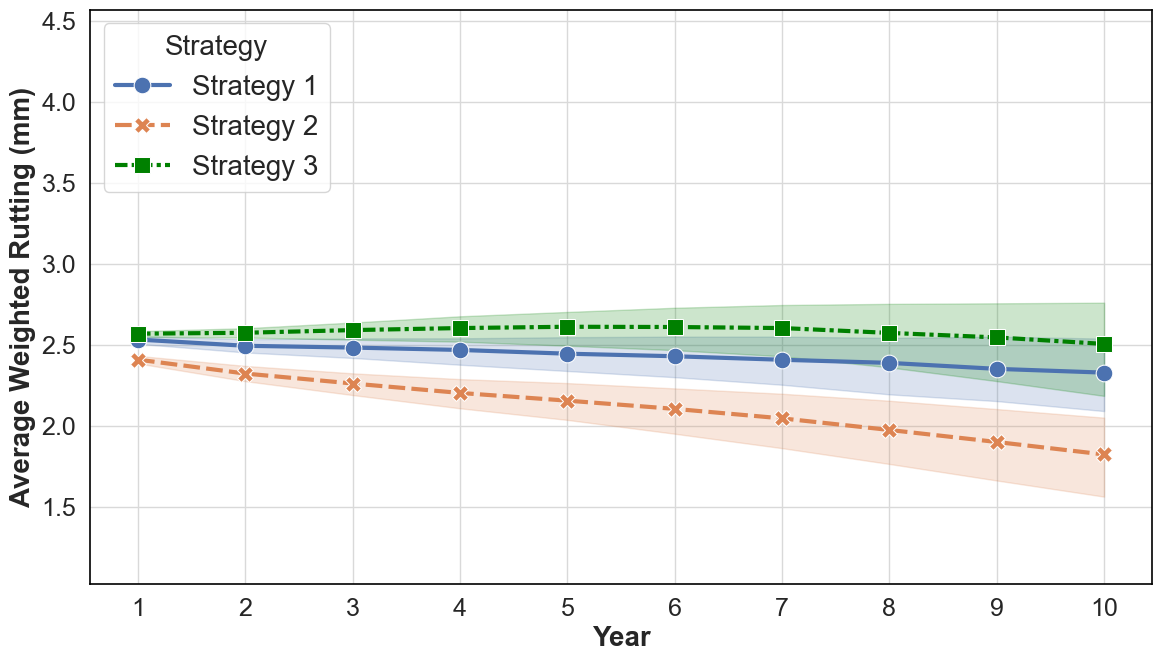

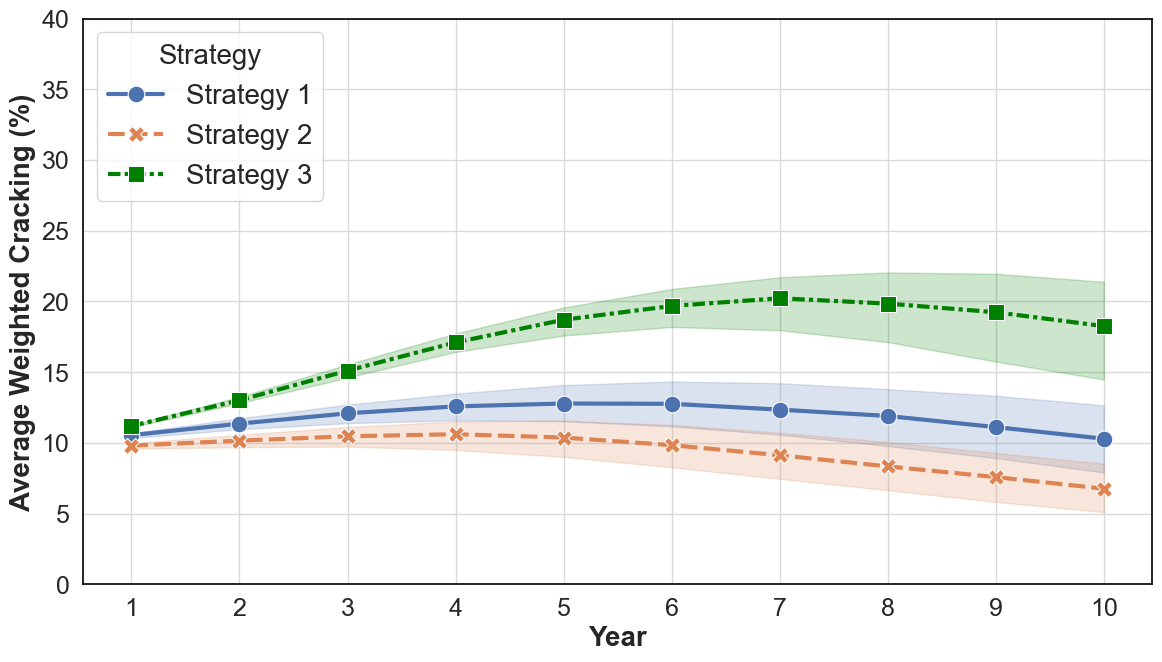

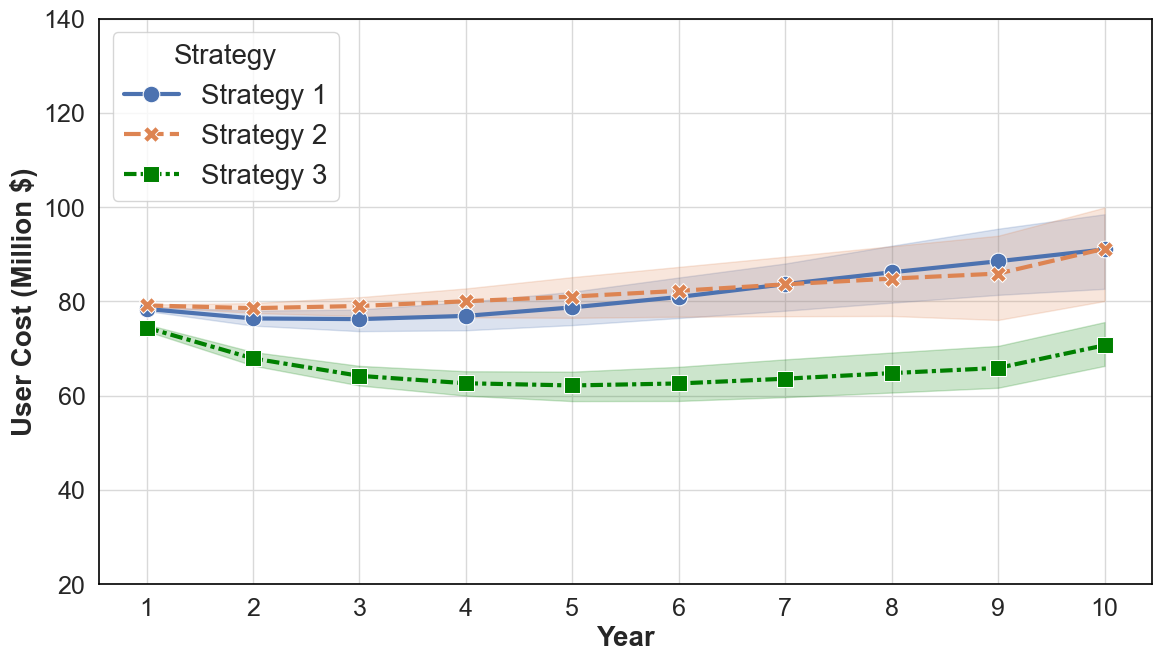

In [2]:
# ============================================================
# Single-budget: strategy comparison
# IRI, Rutting, Cracking, User Cost
# ============================================================

label_map = {
    "Strategy 1":       "Strategy 1",
    "Strategy 2":      "Strategy 2",
    "Strategy 3": "Strategy 3",
}

METRICS_SINGLE = [
    ("weighted_avg_iri",      "Average Weighted IRI (m/km)",   (0.95, 2.53)),
    ("weighted_avg_rutting",  "Average Weighted Rutting (mm)",  (1.02, 4.57)),
    ("weighted_avg_cracking", "Average Weighted Cracking (%)",  (0, 40)),
    ("user_cost",             "User Cost (Million $)",          (20, 140)),
]

for metric_col, ylabel, ylims in METRICS_SINGLE:
    frames = {
        "Strategy 1":       worst_single,
        "Strategy 2":      benefit_single,
        "Strategy 3": benefitA_single,
    }
    plot_strategy_comparison(frames, value_col=metric_col, ylabel=ylabel, y_limits=ylims, label_map=label_map)

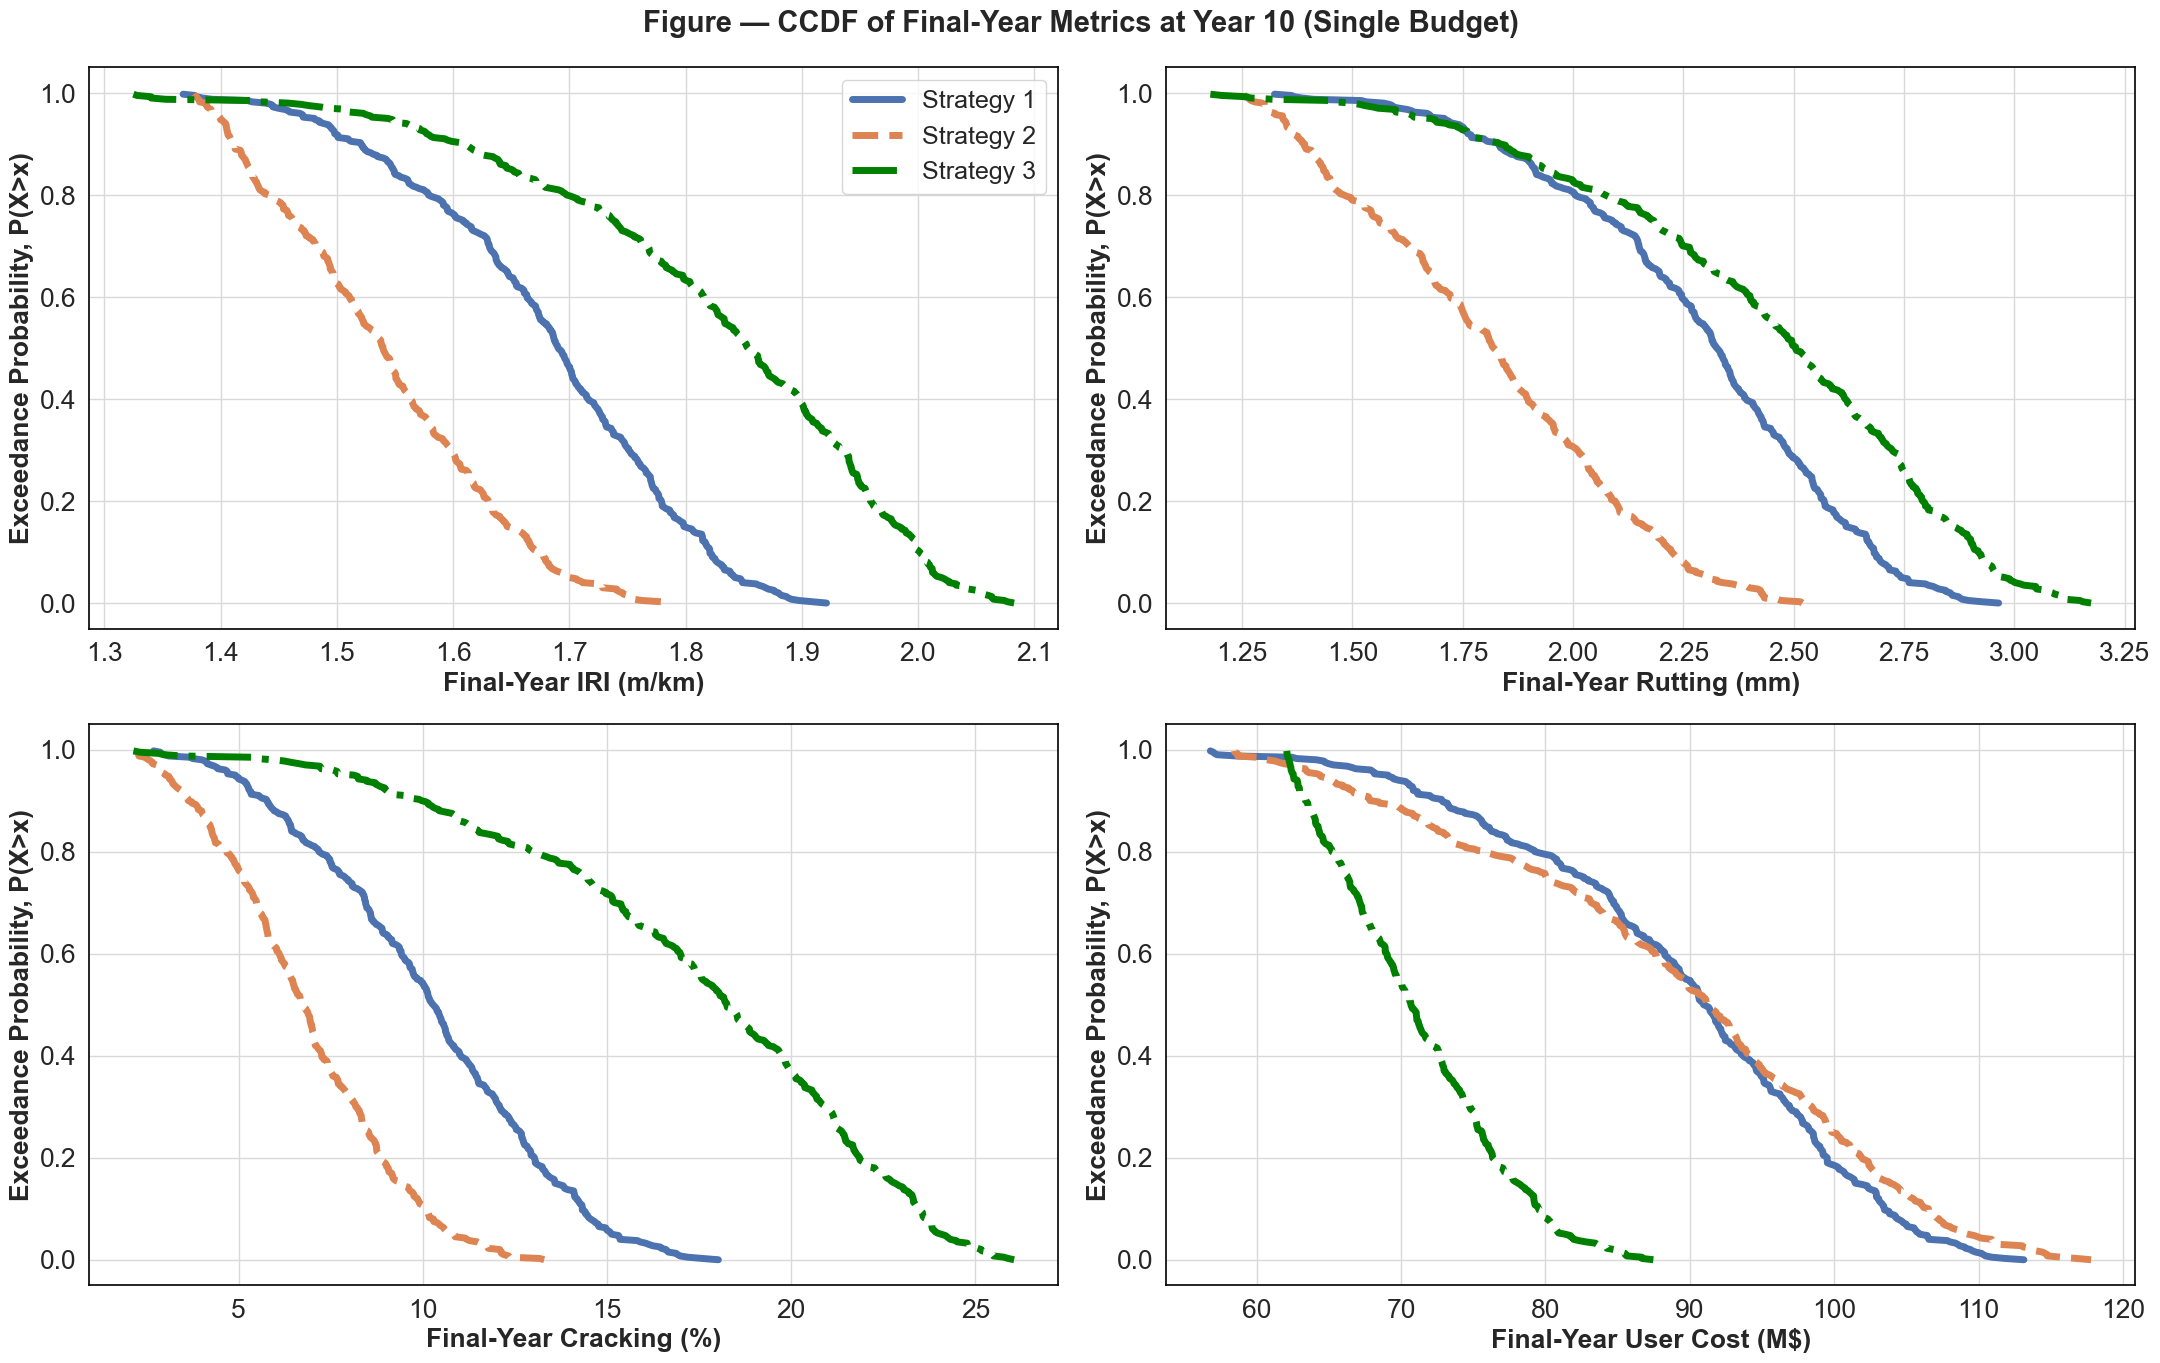

In [3]:
# ============================================================
# 2. CCDF curves — final-year distribution across strategies
#    2×2 subplots: IRI, Rutting, Cracking, User Cost
#    CCDF = 1 - CDF  →  P(X > x)
# ============================================================

CCDF_METRICS = [
    ("weighted_avg_iri",      "Final-Year IRI (m/km)"),
    ("weighted_avg_rutting",  "Final-Year Rutting (mm)"),
    ("weighted_avg_cracking", "Final-Year Cracking (%)"),
    ("user_cost",             "User Cost (M$)"),
]

CDF_STRATS = [
    ("Strategy 1",  worst_single,    "Strategy 1"),
    ("Strategy 2", benefit_single,  "Strategy 2"),
    ("Strategy 3", benefitA_single, "Strategy 3"),
]

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
axes = axes.flatten()

for ax, (metric_col, metric_label) in zip(axes, CCDF_METRICS):
    for disp_label, df_s, style_key in CDF_STRATS:
        if metric_col == "user_cost":
            vals = np.sort(df_s.groupby("simulation")[metric_col].sum().dropna().values)
        else:
            vals = np.sort(df_s[df_s["year"] == FINAL_YEAR][metric_col].dropna().values)
        ccdf = 1 - np.arange(1, len(vals) + 1) / len(vals)
        style = STRATEGY_STYLES[style_key]
        sns.lineplot(x=vals, y=ccdf, ax=ax,
                     color=style["color"], linewidth=LINEWIDTH + 2, linestyle=style.get("linestyle", "-"),
                     label=style["label"],
                     estimator=None, errorbar=None, sort=False, legend=False)

    x_label = "User Cost (M$)" if metric_col == "user_cost" else metric_label
    ax.set_xlabel(x_label, fontsize=19, fontweight="bold")  # increased from 18 to 19
    ax.set_ylabel("Exceedance Probability, P(X>x)", fontsize=19, fontweight="bold")  # 18->19
    ax.tick_params(labelsize=19)  # 16->17 for both x and y
    if metric_col == "weighted_avg_iri":
        legend = ax.legend(fontsize=18, loc="upper right")  # 15->16
        if legend:
            legend.set_title(legend.get_title().get_text(), prop={'size': 24, 'weight': 'bold'})  # 20->21 for legend title
    ax.set_ylim(-0.05, 1.05)

fig.suptitle(f"Figure — CCDF of Final-Year Metrics at Year {FINAL_YEAR} (Single Budget)",
             fontsize=21, fontweight="bold")  # 20->21
plt.tight_layout()
plt.show()

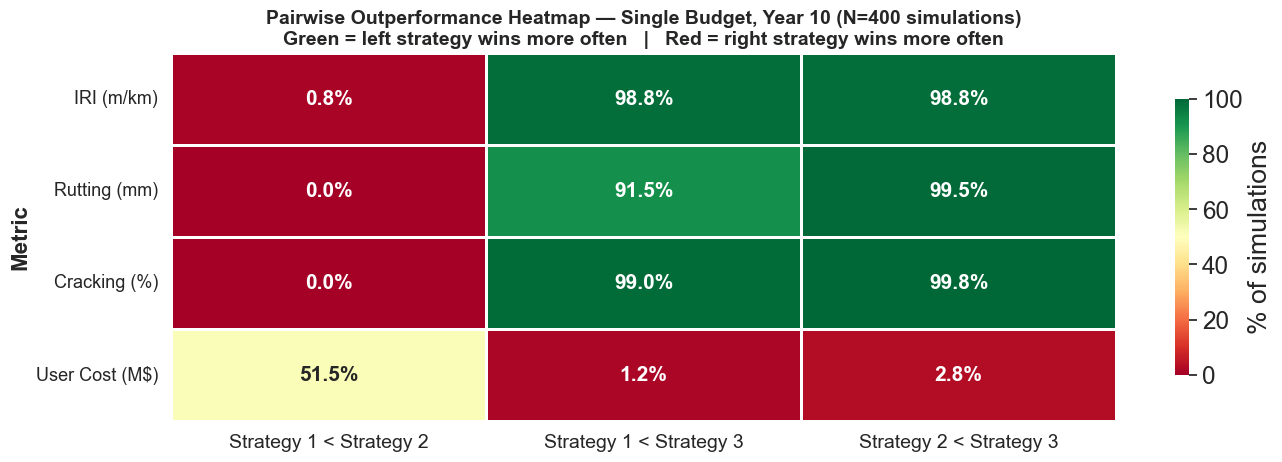

In [4]:
# ============================================================
# Heatmap: pairwise outperformance across 1000 simulations
# Single budget, Year 10  |  lower value = better for all metrics
# Cell = % of simulations where strategy A < strategy B
# ============================================================

METRICS_HM = [
    ("weighted_avg_iri",      "IRI (m/km)"),
    ("weighted_avg_rutting",  "Rutting (mm)"),
    ("weighted_avg_cracking", "Cracking (%)"),
    ("user_cost",             "User Cost (M$)"),
]
HM_COLS = ["weighted_avg_iri", "weighted_avg_rutting",
           "weighted_avg_cracking", "user_cost"]

# final-year values indexed by simulation
wf_fy  = worst_single[worst_single["year"]   == FINAL_YEAR].set_index("simulation")[HM_COLS]
bc_fy  = benefit_single[benefit_single["year"] == FINAL_YEAR].set_index("simulation")[HM_COLS]
bca_fy = benefitA_single[benefitA_single["year"] == FINAL_YEAR].set_index("simulation")[HM_COLS]

idx = wf_fy.index.intersection(bc_fy.index).intersection(bca_fy.index)
wf_fy, bc_fy, bca_fy = wf_fy.loc[idx], bc_fy.loc[idx], bca_fy.loc[idx]
N = len(idx)

comparisons = [
    ("Strategy 1 < Strategy 2",    wf_fy,  bc_fy),
    ("Strategy 1 < Strategy 3",     wf_fy,  bca_fy),
    ("Strategy 2 < Strategy 3",  bc_fy,  bca_fy),
]

pct_rows = []
for col, metric_label in METRICS_HM:
    pct_row = {}
    for comp_label, a_df, b_df in comparisons:
        c = int((a_df[col].values < b_df[col].values).sum())
        pct_row[comp_label] = round(c / N * 100, 1)
    pct_rows.append(pct_row)

metric_labels = [m for _, m in METRICS_HM]
pcts_df = pd.DataFrame(pct_rows, index=metric_labels)

annot = pcts_df.astype(str) + "%"

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pcts_df, annot=annot, fmt="", cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.8, linecolor="white",
            annot_kws={"size": 15, "weight": "bold"},
            cbar_kws={"label": "% of simulations", "shrink": 0.75},
            ax=ax)
ax.set_ylabel("Metric", fontsize=16, fontweight="bold")
ax.set_title(
    f"Pairwise Outperformance Heatmap — Single Budget, Year {FINAL_YEAR} (N={N} simulations)\n"
    f"Green = left strategy wins more often   |   Red = right strategy wins more often",
    fontsize=14, fontweight="bold")
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=13, rotation=0)
plt.tight_layout()
plt.show()

## Multi budget


────────────────────────────────────────────────────────────
  Strategy 2
────────────────────────────────────────────────────────────


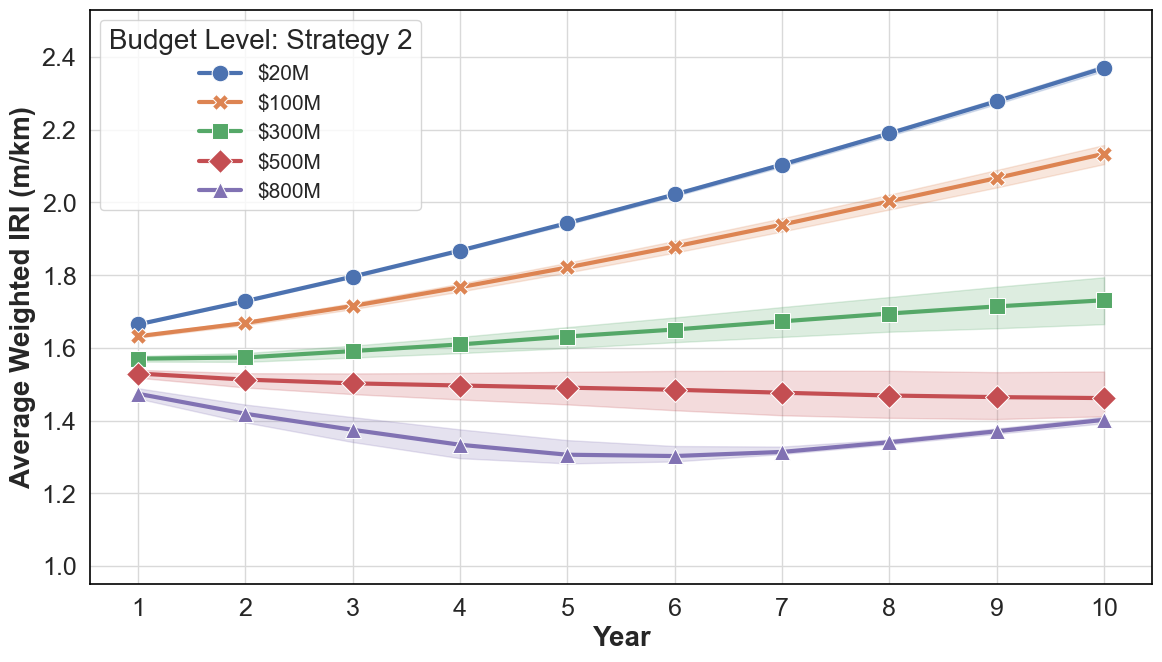

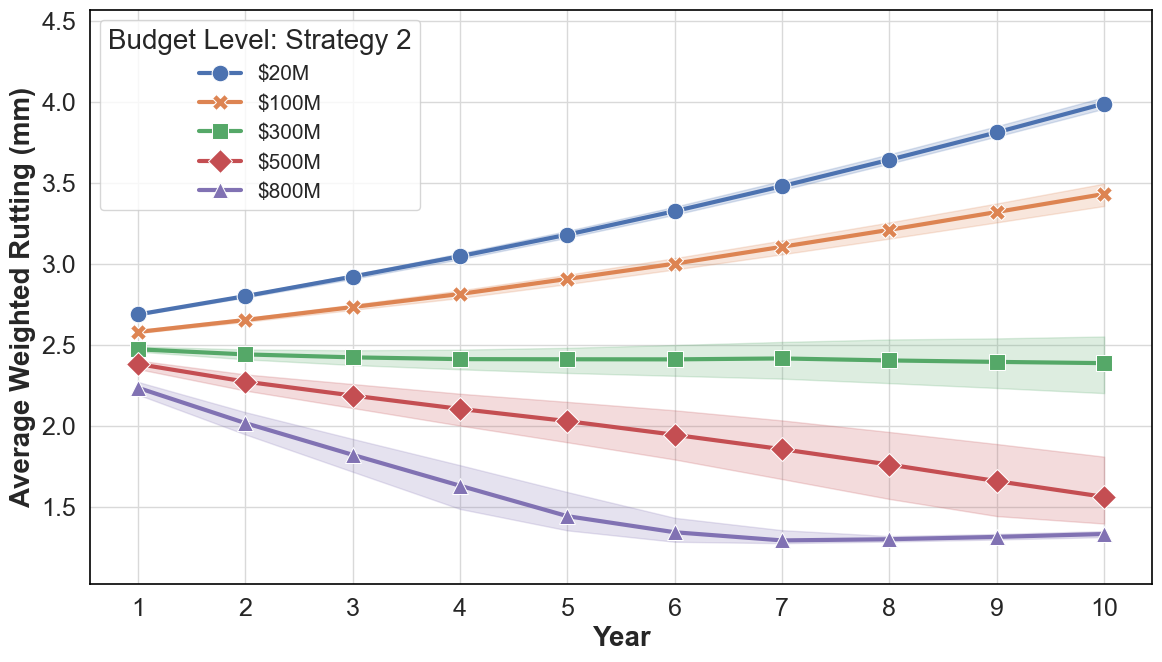

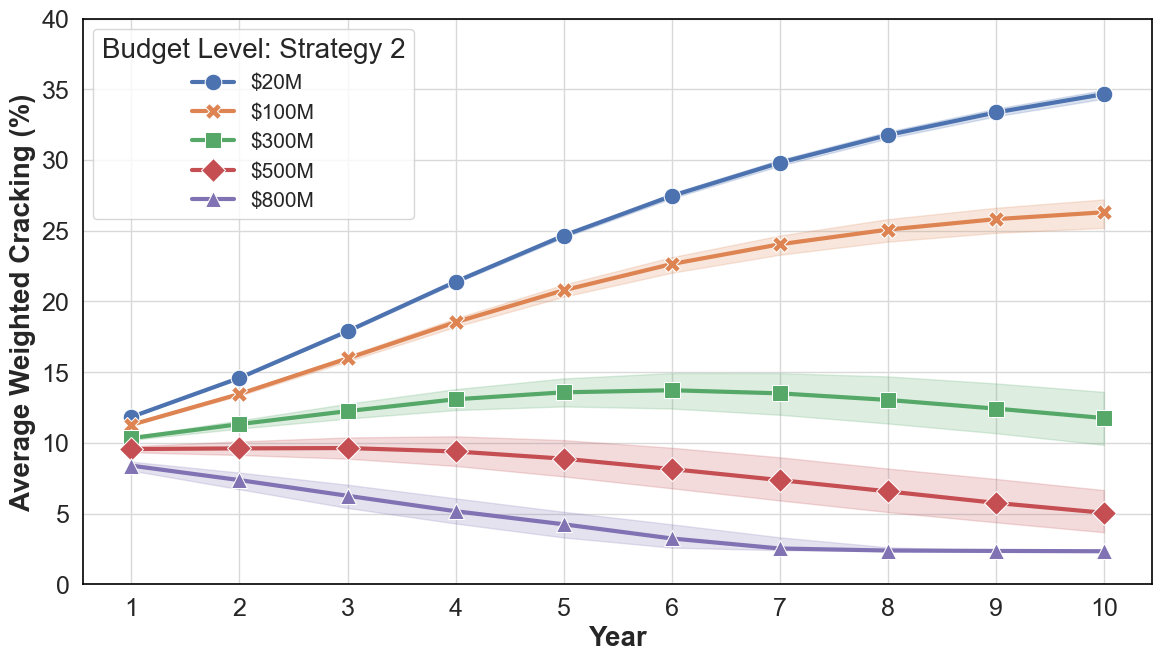

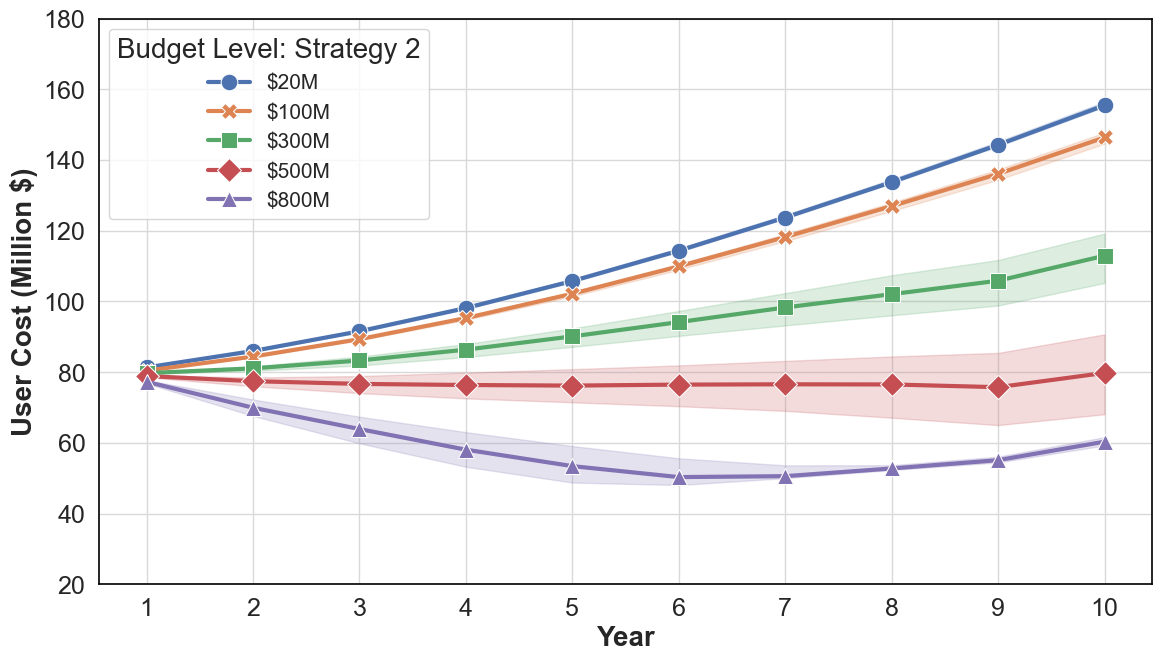


────────────────────────────────────────────────────────────
  Strategy 3
────────────────────────────────────────────────────────────


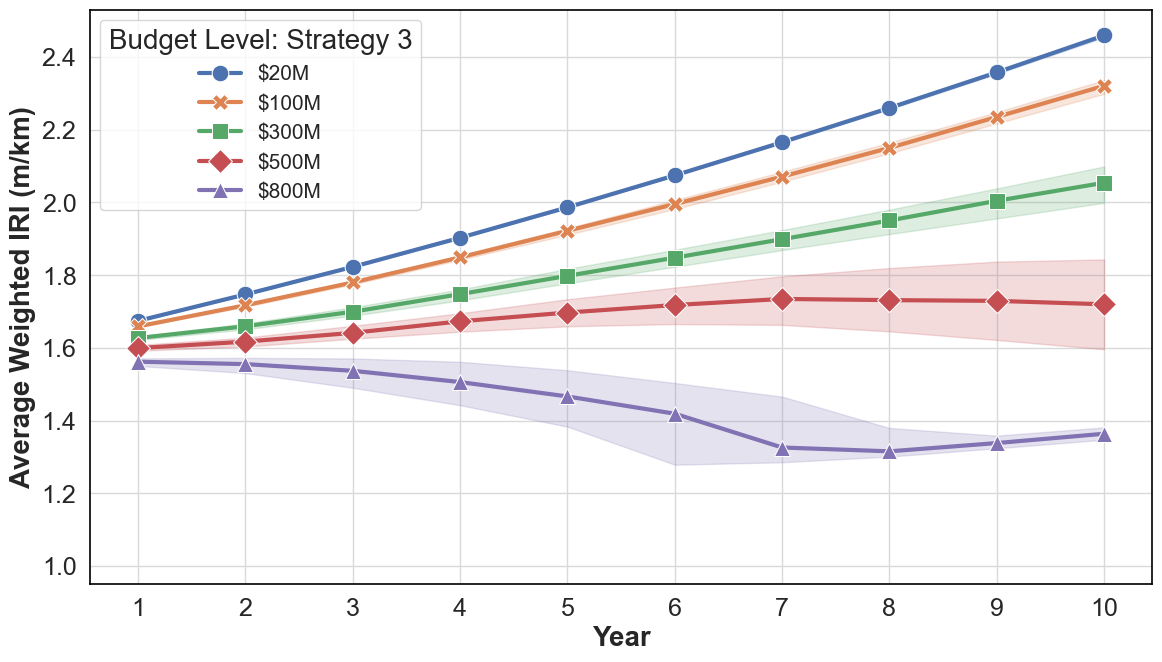

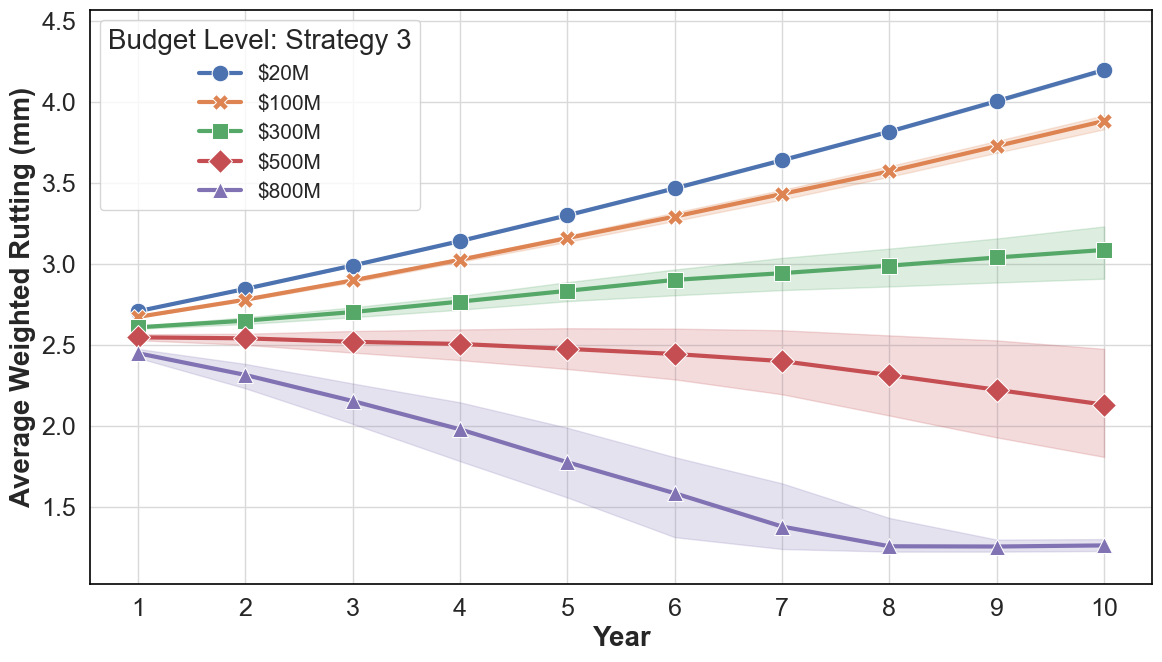

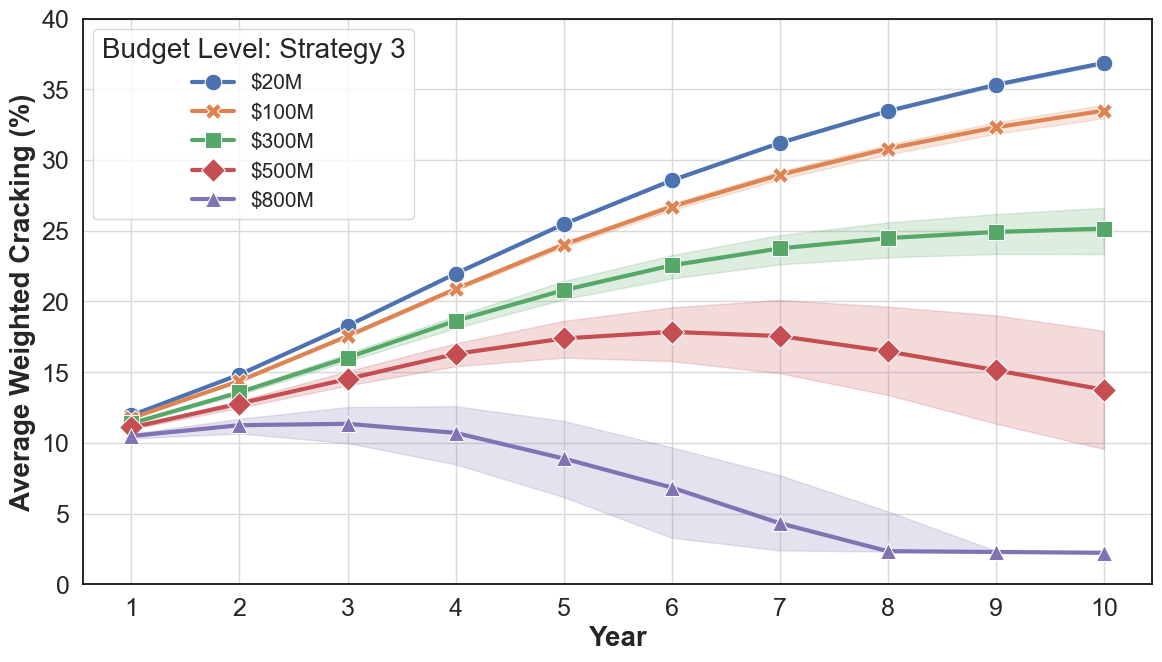

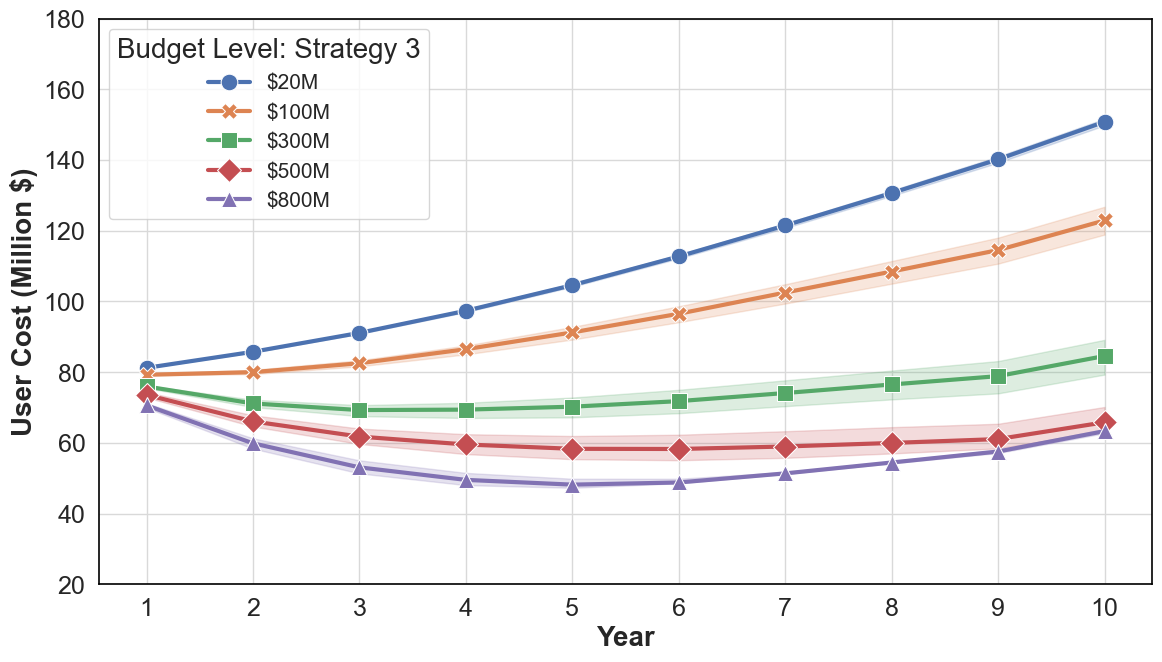


────────────────────────────────────────────────────────────
  Strategy 1
────────────────────────────────────────────────────────────


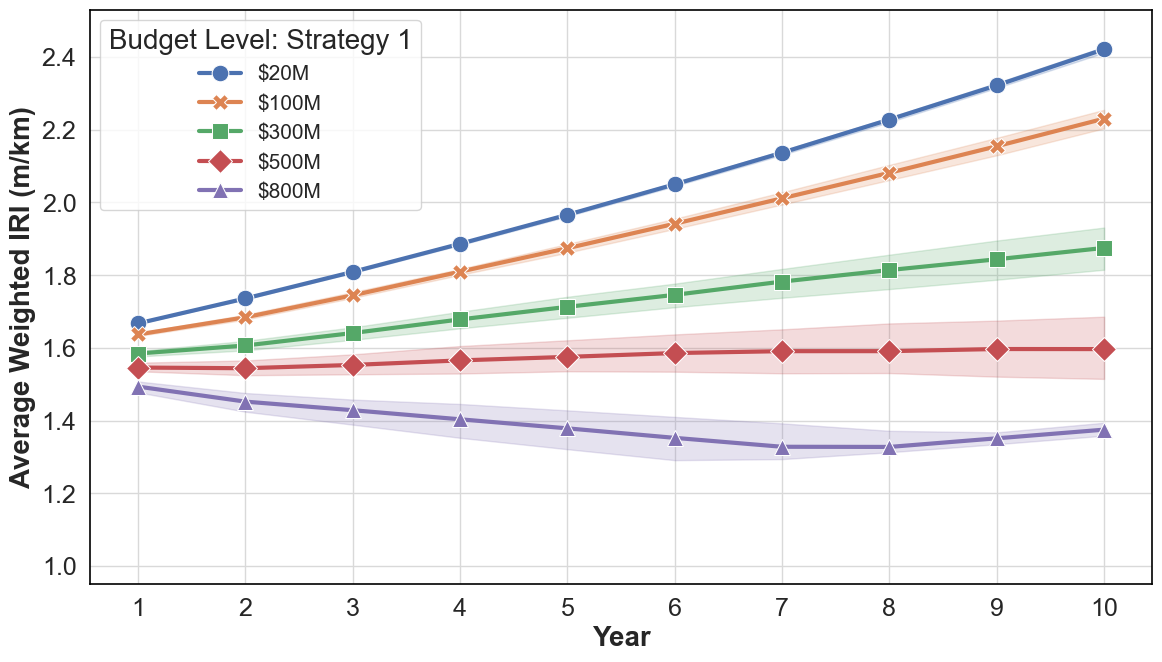

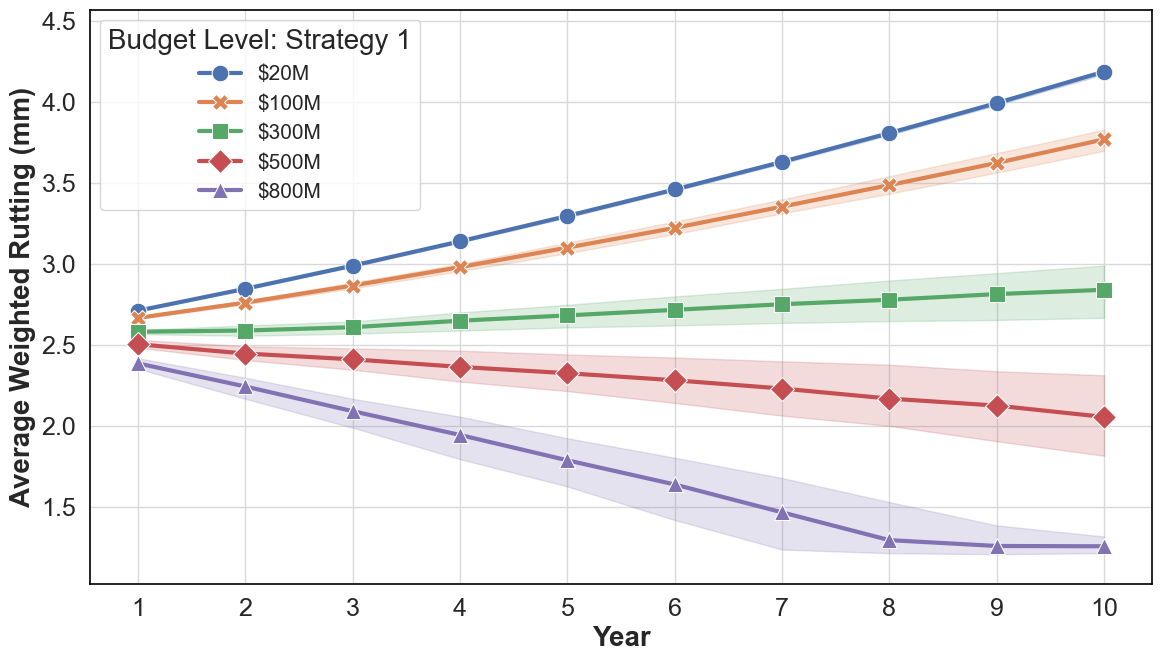

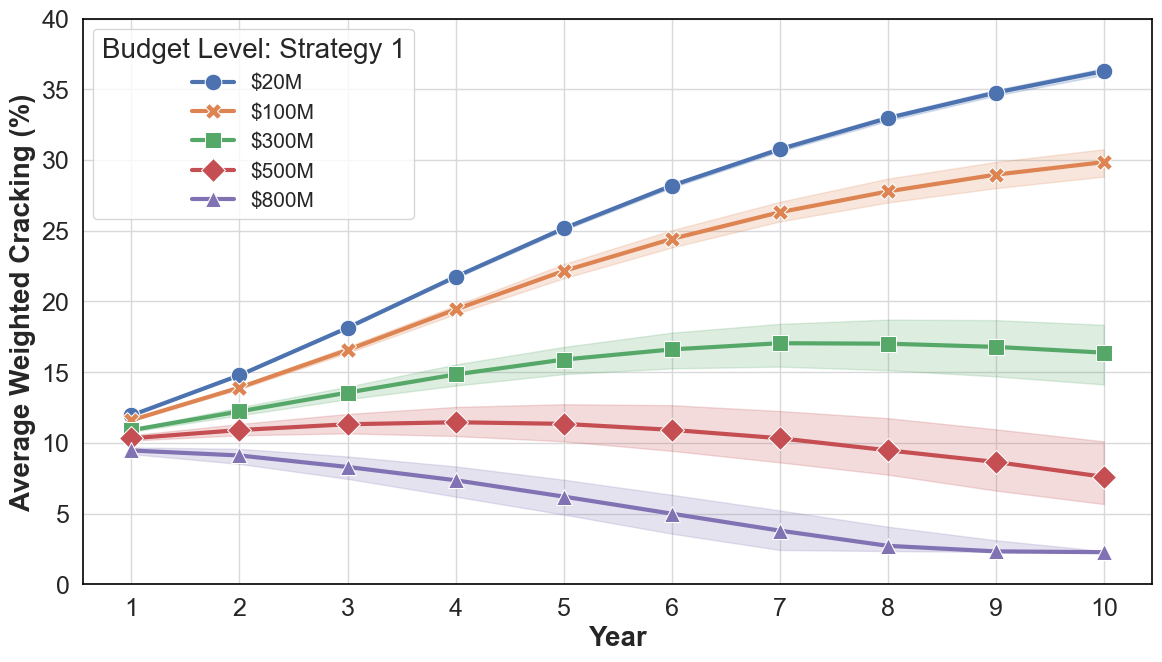

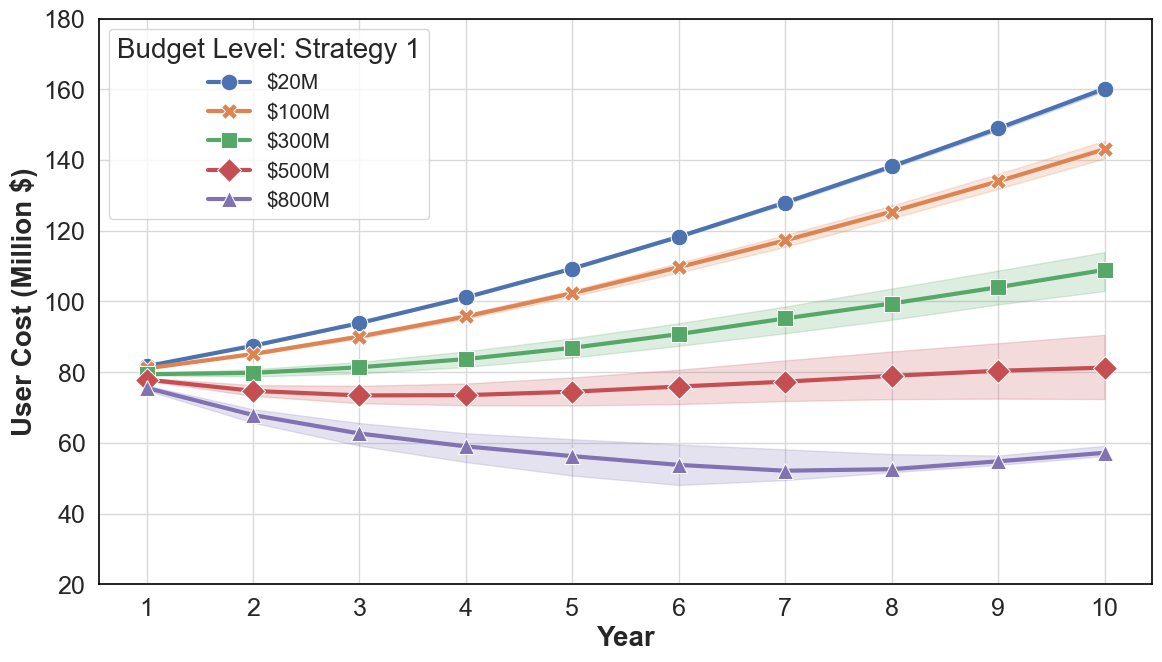

In [5]:
# ============================================================
# Multi-budget: IRI, Rutting, Cracking, User Cost – per strategy
# ============================================================

METRICS_MULTI = [
    ("weighted_avg_iri",      "Average Weighted IRI (m/km)",   0.95,   2.53),
    ("weighted_avg_rutting",  "Average Weighted Rutting (mm)",  1.02, 4.57),
    ("weighted_avg_cracking", "Average Weighted Cracking (%)",  0,    40),
    ("user_cost",             "User Cost (Million $)",          20,   180),
]

for strat_label, df_m in [
    ("Strategy 2",                   benefit_multi),
    ("Strategy 3", benefitA_multi),
    ("Strategy 1",                    worst_multi),
]:
    print(f"\n{'─' * 60}\n  {strat_label}\n{'─' * 60}")
    for metric_col, ylabel, ymin, ymax in METRICS_MULTI:
        plot_metric_by_budget(
            df=df_m,
            metric_col=metric_col,
            y_label=ylabel,
            y_min=ymin,
            y_max=ymax,
            legend_title=f"Budget Level: {strat_label}",
        )

## Scenario 2 – Performance + Cost Uncertainty (COV_IRI = 0.15)

Both treatment cost uncertainty and performance model uncertainty are active.
Results loaded from `*_cov0.15.csv` files.

In [6]:
# ============================================================
# Scenario 2 – Data loading (COV_IRI = 0.15)
# All six CSVs from Correlation_0.15 folder
# ============================================================

BASE_PATH_S2 = pathlib.Path("Correlation_0.15")
COV_TAG_S2   = "_cov0.15"

worst_single_s2    = pd.read_csv(BASE_PATH_S2 / f"single_budget_simulation_worstfirst{COV_TAG_S2}.csv")
benefit_single_s2  = pd.read_csv(BASE_PATH_S2 / f"single_budget_simulation_benefit{COV_TAG_S2}.csv")
benefitA_single_s2 = pd.read_csv(BASE_PATH_S2 / f"single_budget_simulation_benefit_aadt{COV_TAG_S2}.csv")

worst_multi_s2     = pd.read_csv(BASE_PATH_S2 / f"multi_budget_simulation_results_worstfirst{COV_TAG_S2}.csv")
benefit_multi_s2   = pd.read_csv(BASE_PATH_S2 / f"multi_budget_simulation_results_benefit{COV_TAG_S2}.csv")
benefitA_multi_s2  = pd.read_csv(BASE_PATH_S2 / f"multi_budget_simulation_results_benefit_aadt{COV_TAG_S2}.csv")

for _df in (worst_single_s2, benefit_single_s2, benefitA_single_s2, worst_multi_s2, benefit_multi_s2, benefitA_multi_s2):
    _df["weighted_avg_iri"] *= IRI_IN_MI_TO_M_KM
    _df["weighted_avg_rutting"] *= RUTTING_IN_TO_MM
    _df["user_cost"] *= CPI_ADJUSTMENT_2025

FINAL_YEAR_S2 = int(worst_single_s2["year"].max())

print("Scenario 2 loaded (COV_IRI = 0.15):")
print(f"  Single — Strategy 1: {worst_single_s2.shape} | Strategy 2: {benefit_single_s2.shape} | Strategy 3: {benefitA_single_s2.shape}")
print(f"  Multi  — Strategy 1: {worst_multi_s2.shape}  | Strategy 2: {benefit_multi_s2.shape}  | Strategy 3: {benefitA_multi_s2.shape}")
print(f"  FINAL_YEAR_S2: {FINAL_YEAR_S2}")


Scenario 2 loaded (COV_IRI = 0.15):
  Single — Strategy 1: (4000, 7) | Strategy 2: (4000, 7) | Strategy 3: (4000, 7)
  Multi  — Strategy 1: (20000, 8)  | Strategy 2: (20000, 8)  | Strategy 3: (20000, 8)
  FINAL_YEAR_S2: 10


## Single budget

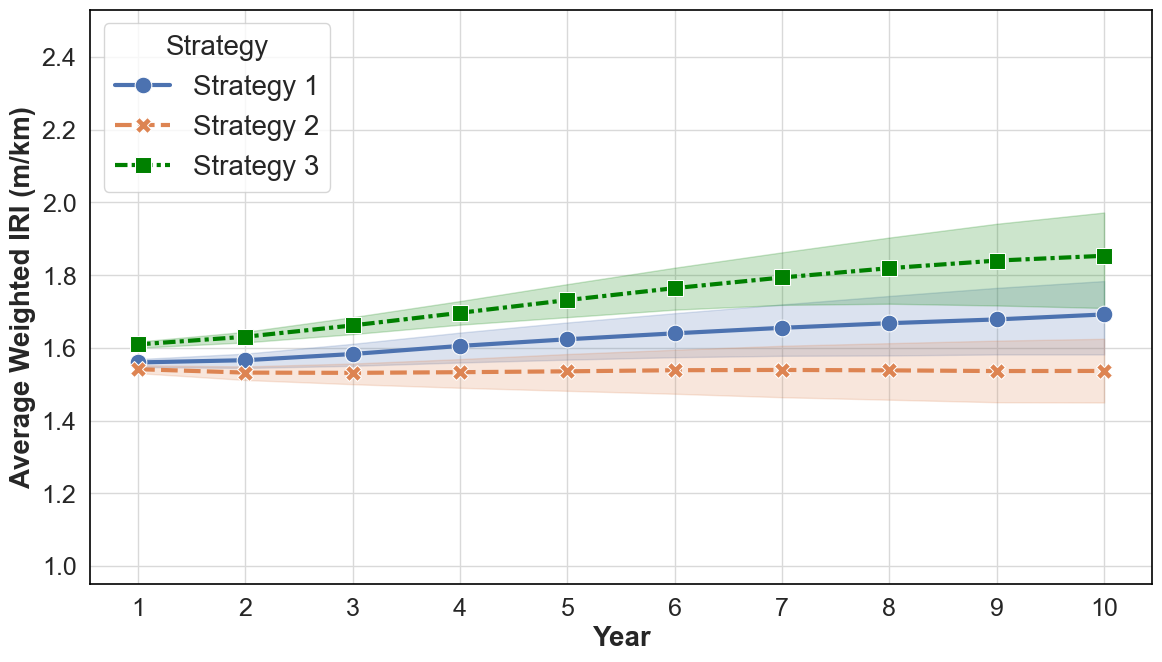

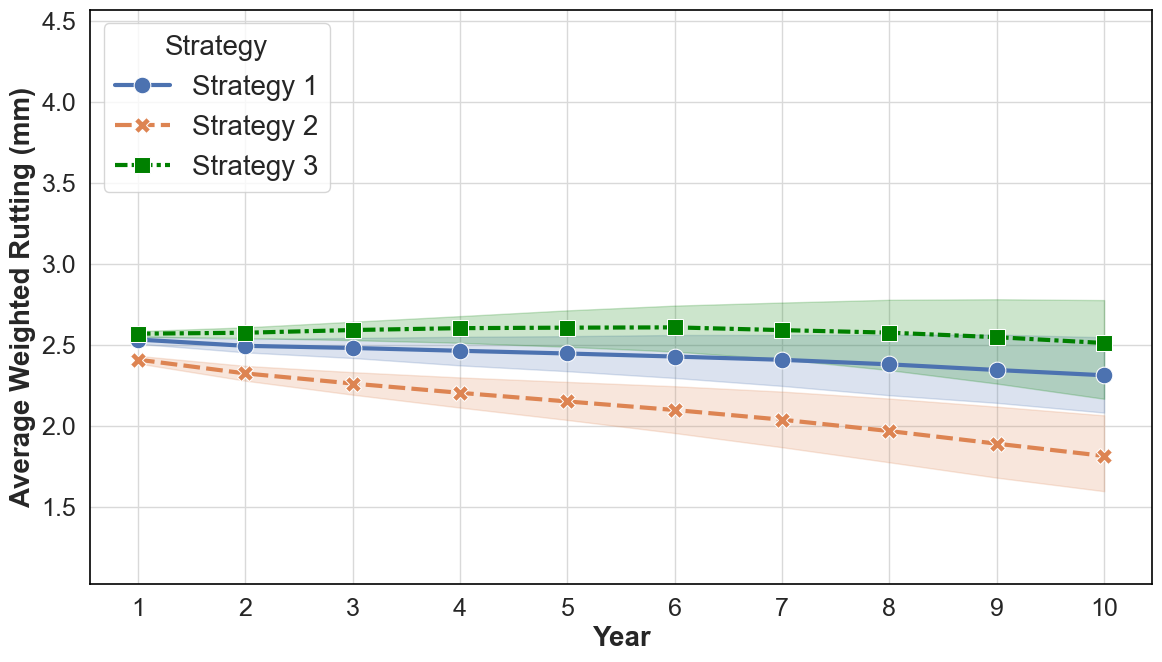

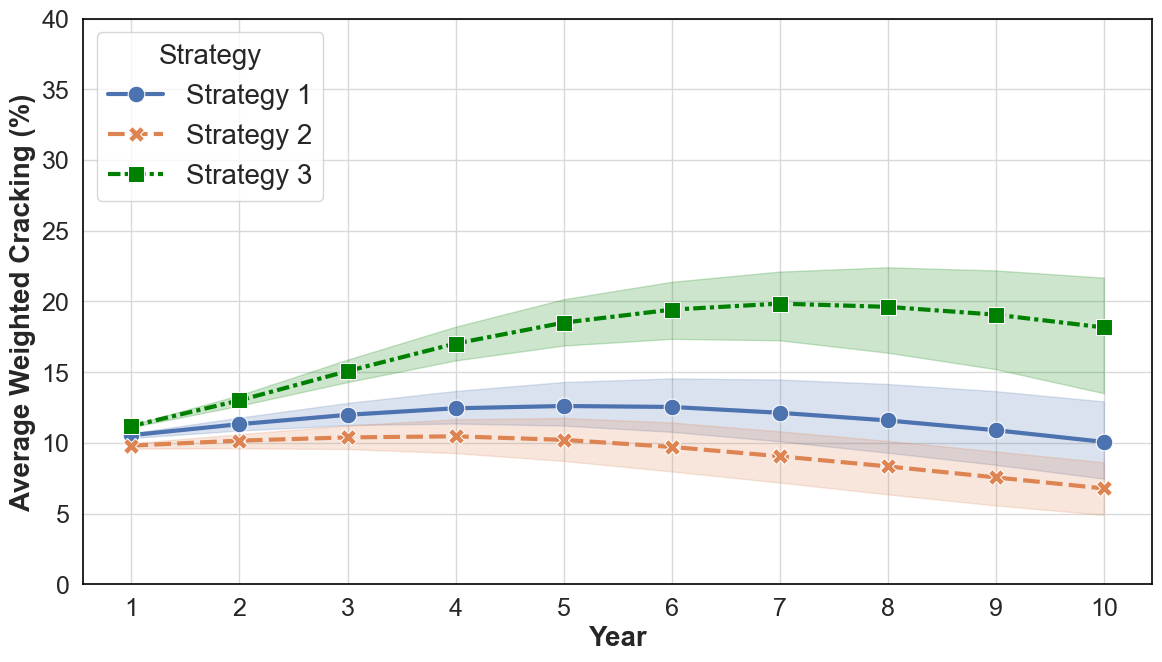

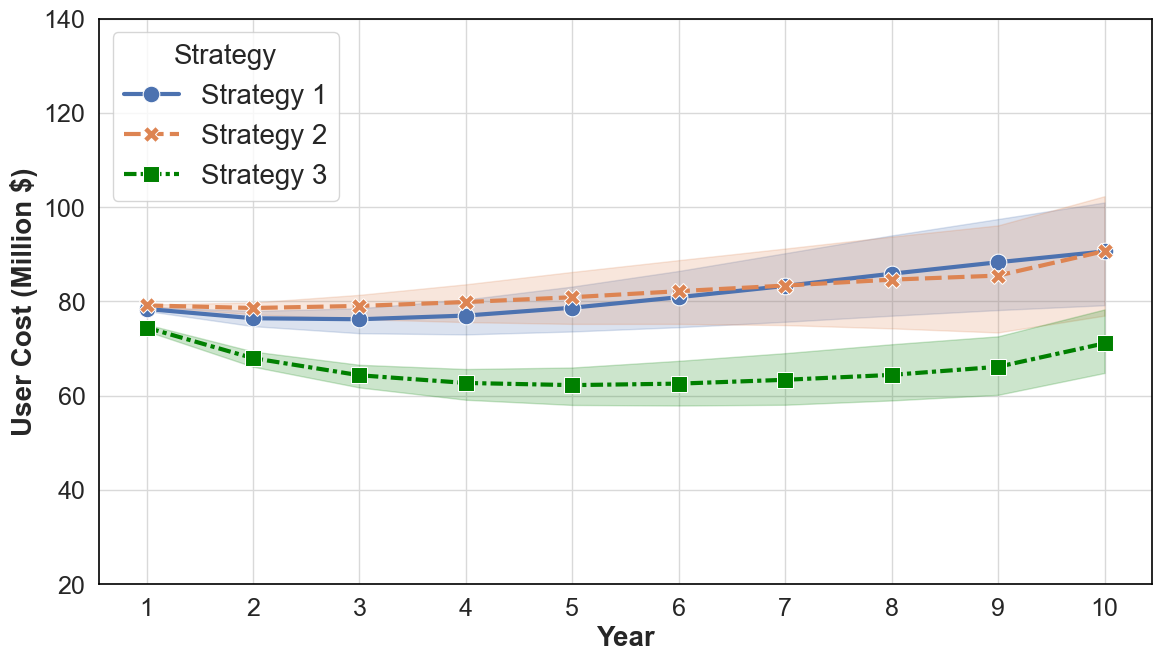

In [7]:
# ============================================================
# Scenario 2 – Single-budget: strategy comparison (COV_IRI = 0.15)
# IRI, Rutting, Cracking, User Cost
# ============================================================

for metric_col, ylabel, ylims in METRICS_SINGLE:
    frames = {
        "Strategy 1":       worst_single_s2,
        "Strategy 2":      benefit_single_s2,
        "Strategy 3": benefitA_single_s2,
    }
    plot_strategy_comparison(frames, value_col=metric_col, ylabel=ylabel, y_limits=ylims, label_map=label_map)


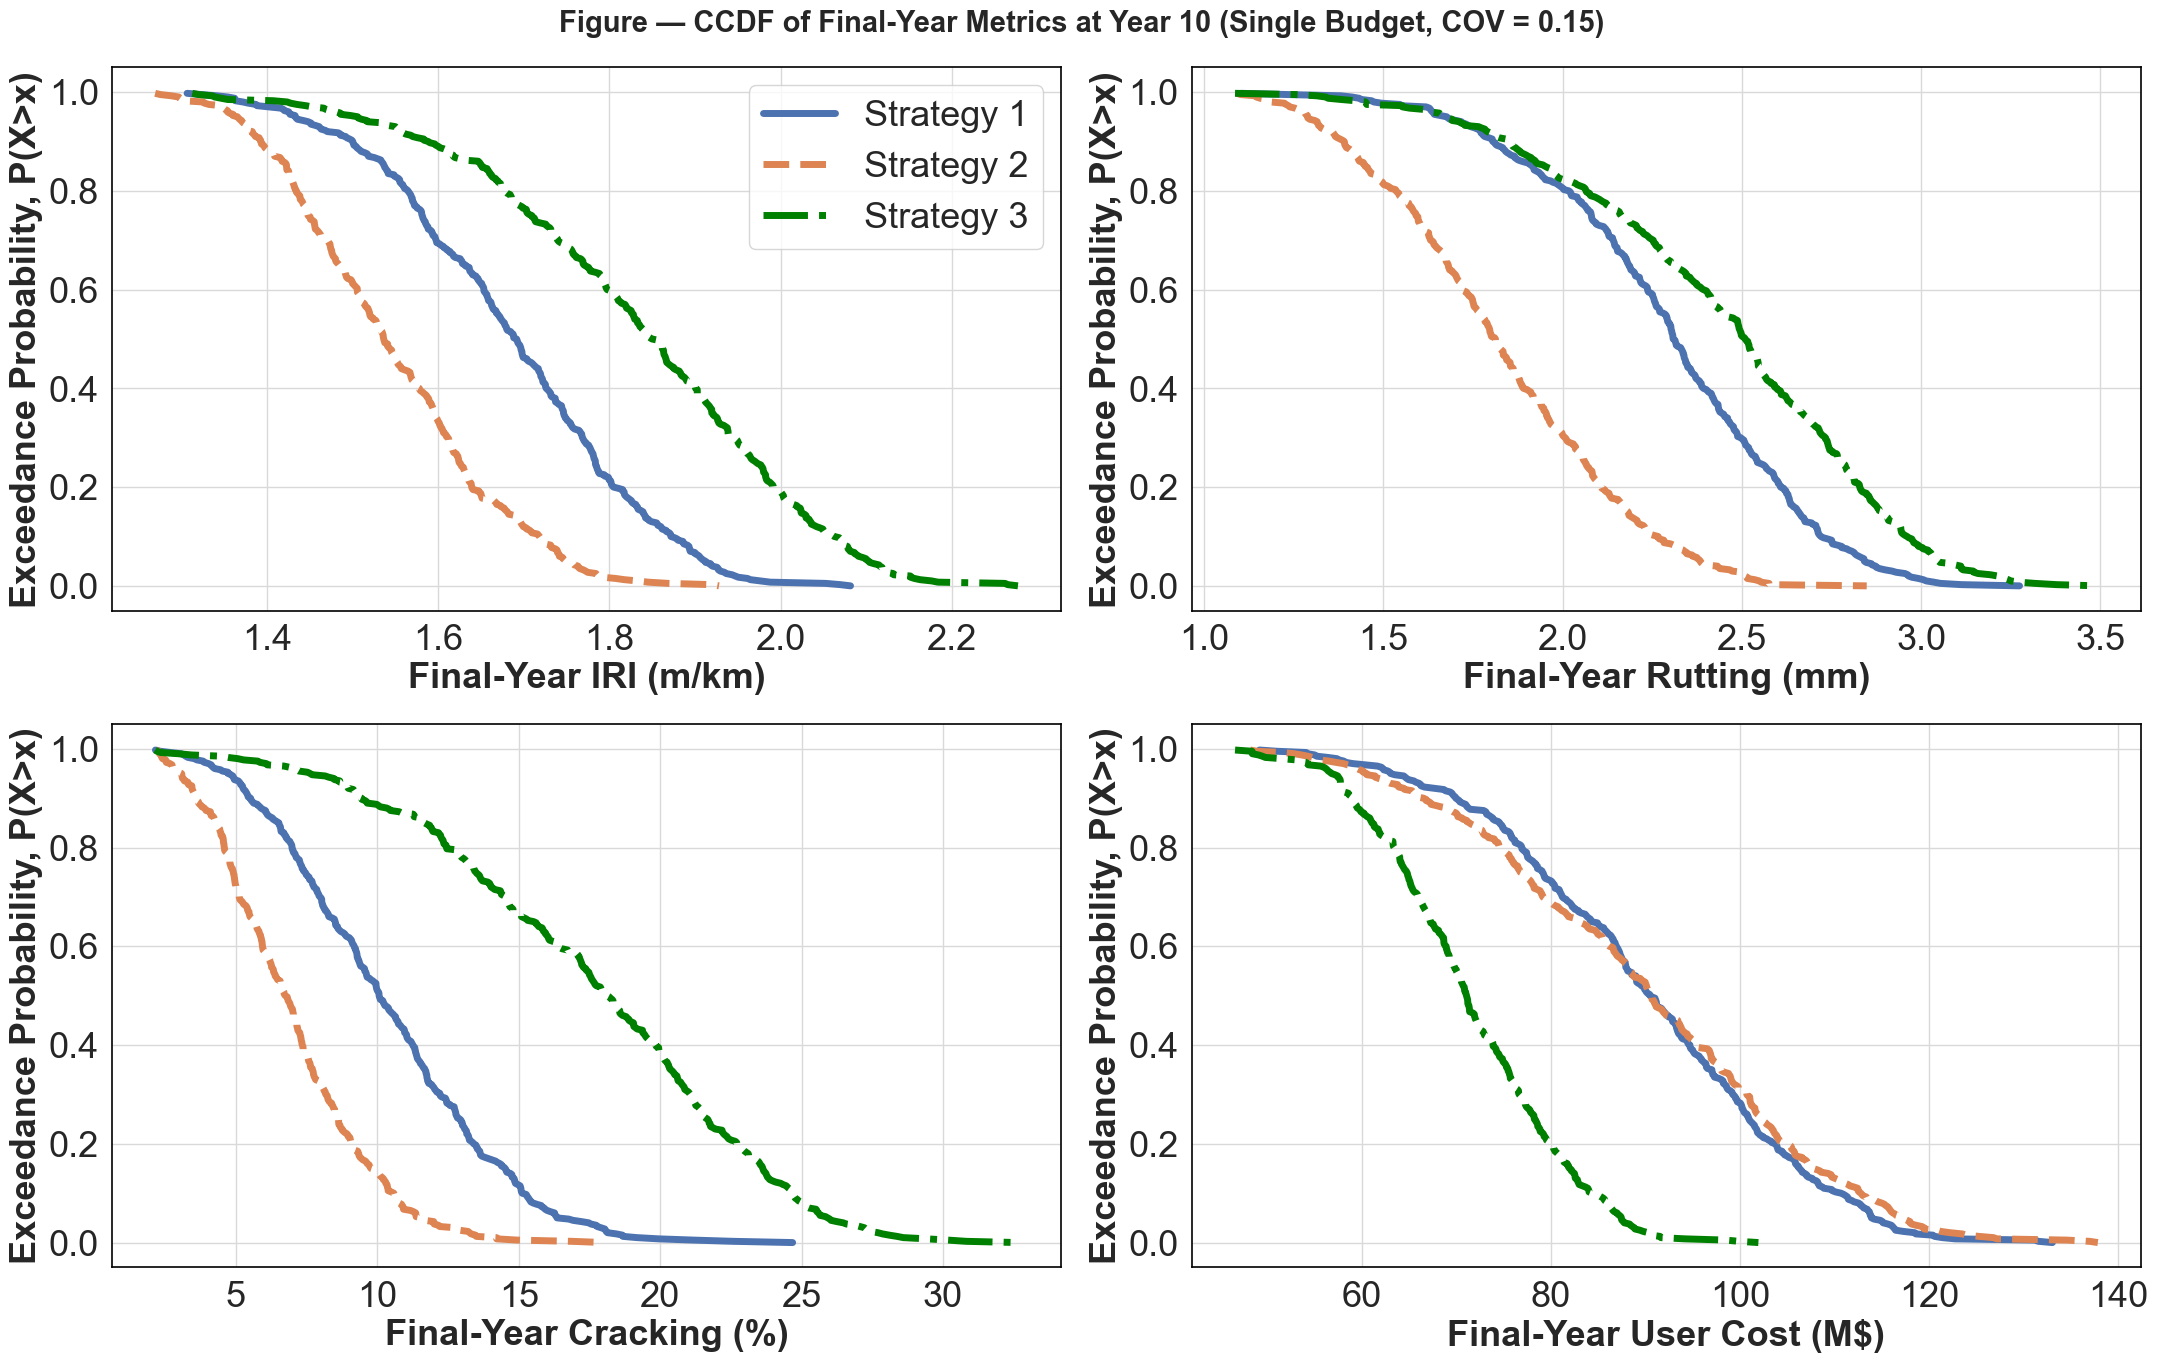

In [8]:
# ============================================================
# Scenario 2 – CCDF curves — final-year distribution (COV_IRI = 0.15)
# 2x2 subplots: IRI, Rutting, Cracking, User Cost
# ============================================================

CDF_STRATS_S2 = [
    ("Strategy 1",  worst_single_s2,    "Strategy 1"),
    ("Strategy 2", benefit_single_s2,  "Strategy 2"),
    ("Strategy 3", benefitA_single_s2, "Strategy 3"),
]

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
axes = axes.flatten()

for ax, (metric_col, metric_label) in zip(axes, CCDF_METRICS):
    for disp_label, df_s, style_key in CDF_STRATS_S2:
        if metric_col == "user_cost":
            vals = np.sort(df_s.groupby("simulation")[metric_col].sum().dropna().values)
        else:
            vals = np.sort(df_s[df_s["year"] == FINAL_YEAR_S2][metric_col].dropna().values)
        ccdf = 1 - np.arange(1, len(vals) + 1) / len(vals)
        style = STRATEGY_STYLES[style_key]
        sns.lineplot(x=vals, y=ccdf, ax=ax,
                     color=style["color"], linewidth=LINEWIDTH + 2, linestyle=style.get("linestyle", "-"),
                     label=style["label"],
                     estimator=None, errorbar=None, sort=False, legend=False)

    x_label = "User Cost (M$)" if metric_col == "user_cost" else metric_label
    ax.set_xlabel(x_label, fontsize=26, fontweight="bold")
    ax.set_ylabel("Exceedance Probability, P(X>x)", fontsize=26, fontweight="bold")
    ax.tick_params(labelsize=26)
    if metric_col == "weighted_avg_iri":
        legend = ax.legend(fontsize=26, loc="upper right")
        if legend:
            legend.set_title(legend.get_title().get_text(), prop={'size': 28, 'weight': 'bold'})
    ax.set_ylim(-0.05, 1.05)

fig.suptitle(f"Figure — CCDF of Final-Year Metrics at Year {FINAL_YEAR_S2} (Single Budget, COV = 0.15)",
             fontsize=21, fontweight="bold")
plt.tight_layout()
plt.show()


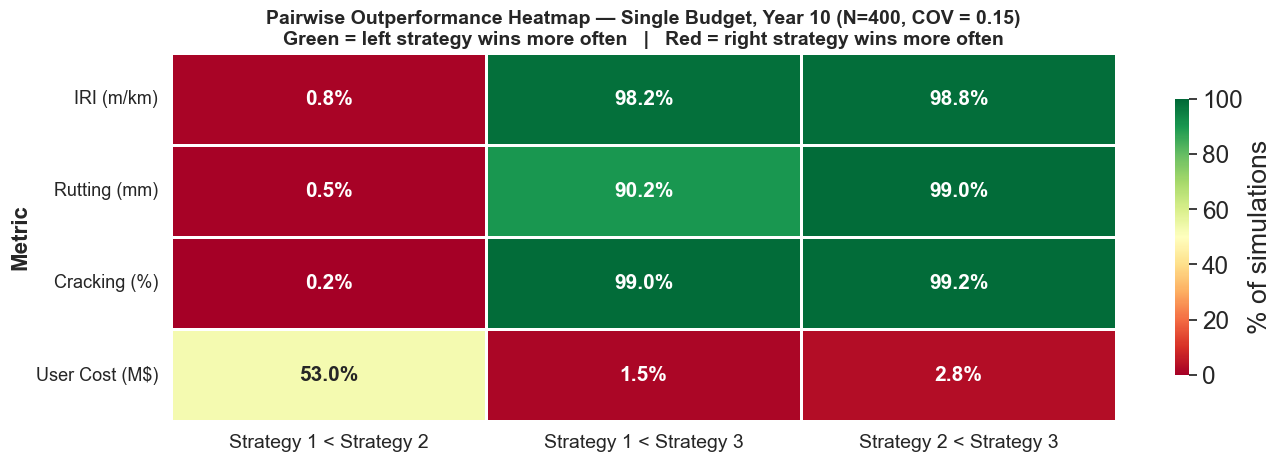

In [9]:
# ============================================================
# Scenario 2 – Pairwise outperformance heatmap (COV_IRI = 0.15)
# Single budget, final year | lower = better for all metrics
# ============================================================

wf_fy_s2  = worst_single_s2[worst_single_s2["year"]     == FINAL_YEAR_S2].set_index("simulation")[HM_COLS]
bc_fy_s2  = benefit_single_s2[benefit_single_s2["year"] == FINAL_YEAR_S2].set_index("simulation")[HM_COLS]
bca_fy_s2 = benefitA_single_s2[benefitA_single_s2["year"] == FINAL_YEAR_S2].set_index("simulation")[HM_COLS]

idx_s2 = wf_fy_s2.index.intersection(bc_fy_s2.index).intersection(bca_fy_s2.index)
wf_fy_s2, bc_fy_s2, bca_fy_s2 = wf_fy_s2.loc[idx_s2], bc_fy_s2.loc[idx_s2], bca_fy_s2.loc[idx_s2]
N_s2 = len(idx_s2)

comparisons_s2 = [
    ("Strategy 1 < Strategy 2",    wf_fy_s2,  bc_fy_s2),
    ("Strategy 1 < Strategy 3",     wf_fy_s2,  bca_fy_s2),
    ("Strategy 2 < Strategy 3",  bc_fy_s2,  bca_fy_s2),
]

pct_rows_s2 = []
for col, metric_label in METRICS_HM:
    pct_row = {}
    for comp_label, a_df, b_df in comparisons_s2:
        c = int((a_df[col].values < b_df[col].values).sum())
        pct_row[comp_label] = round(c / N_s2 * 100, 1)
    pct_rows_s2.append(pct_row)

pcts_df_s2 = pd.DataFrame(pct_rows_s2, index=[m for _, m in METRICS_HM])
annot_s2   = pcts_df_s2.astype(str) + "%"

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pcts_df_s2, annot=annot_s2, fmt="", cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.8, linecolor="white",
            annot_kws={"size": 15, "weight": "bold"},
            cbar_kws={"label": "% of simulations", "shrink": 0.75},
            ax=ax)
ax.set_ylabel("Metric", fontsize=16, fontweight="bold")
ax.set_title(
    f"Pairwise Outperformance Heatmap — Single Budget, Year {FINAL_YEAR_S2} (N={N_s2}, COV = 0.15)\n"
    f"Green = left strategy wins more often   |   Red = right strategy wins more often",
    fontsize=14, fontweight="bold")
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=13, rotation=0)
plt.tight_layout()
plt.show()


## Multi budget


────────────────────────────────────────────────────────────
  Strategy 2 (COV = 0.15)
────────────────────────────────────────────────────────────


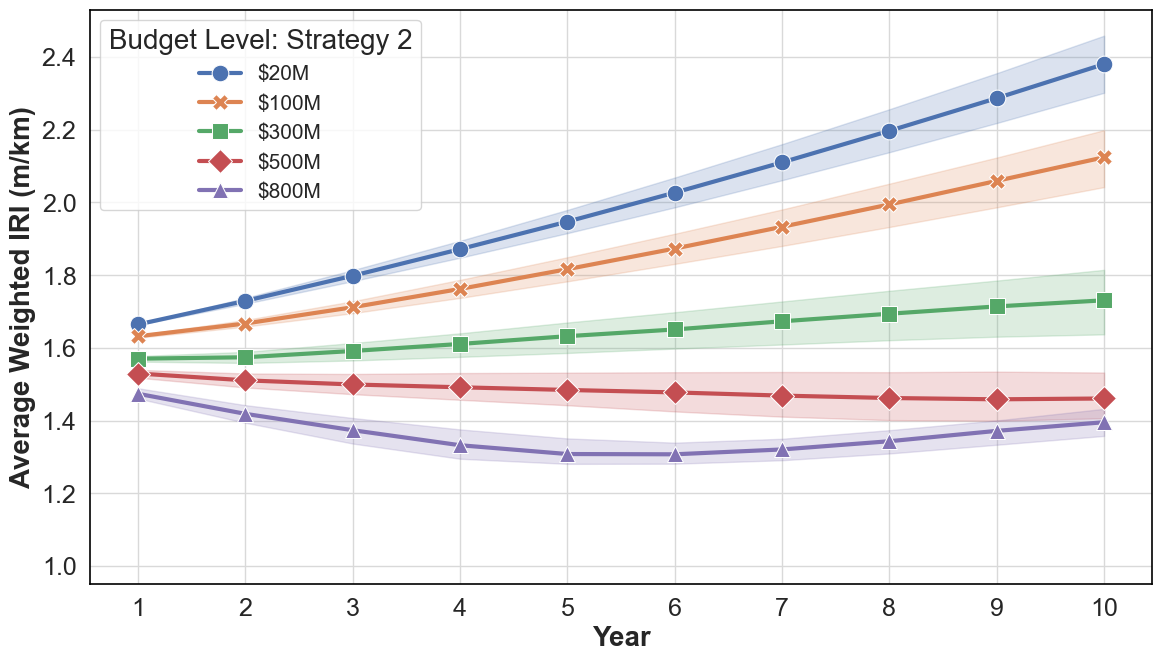

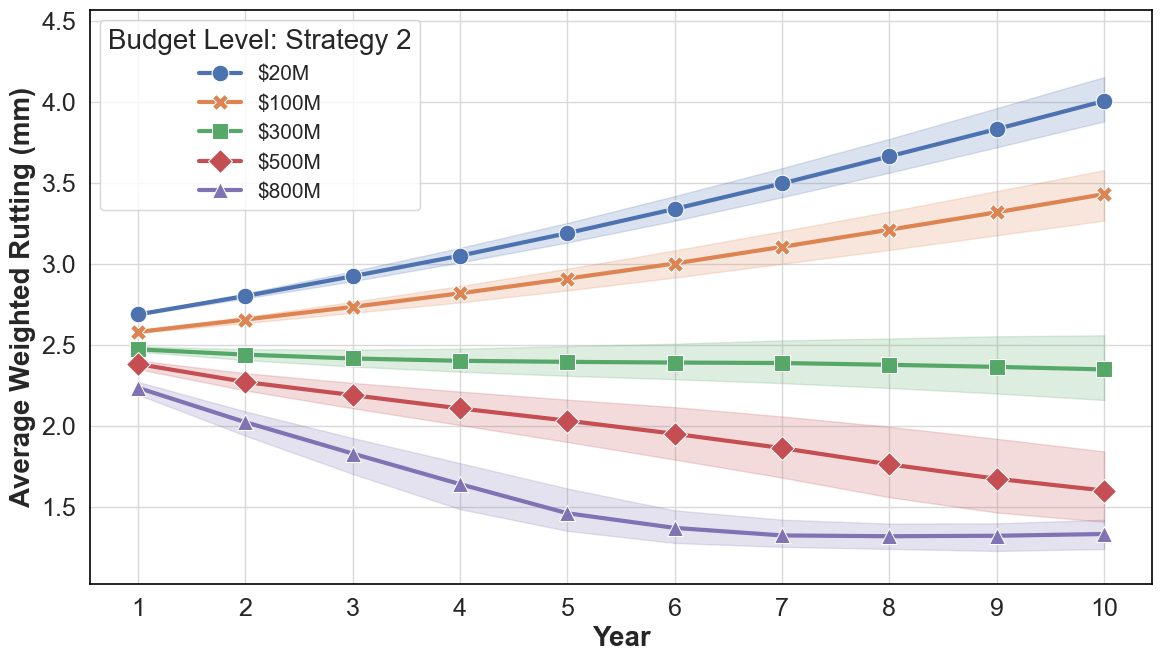

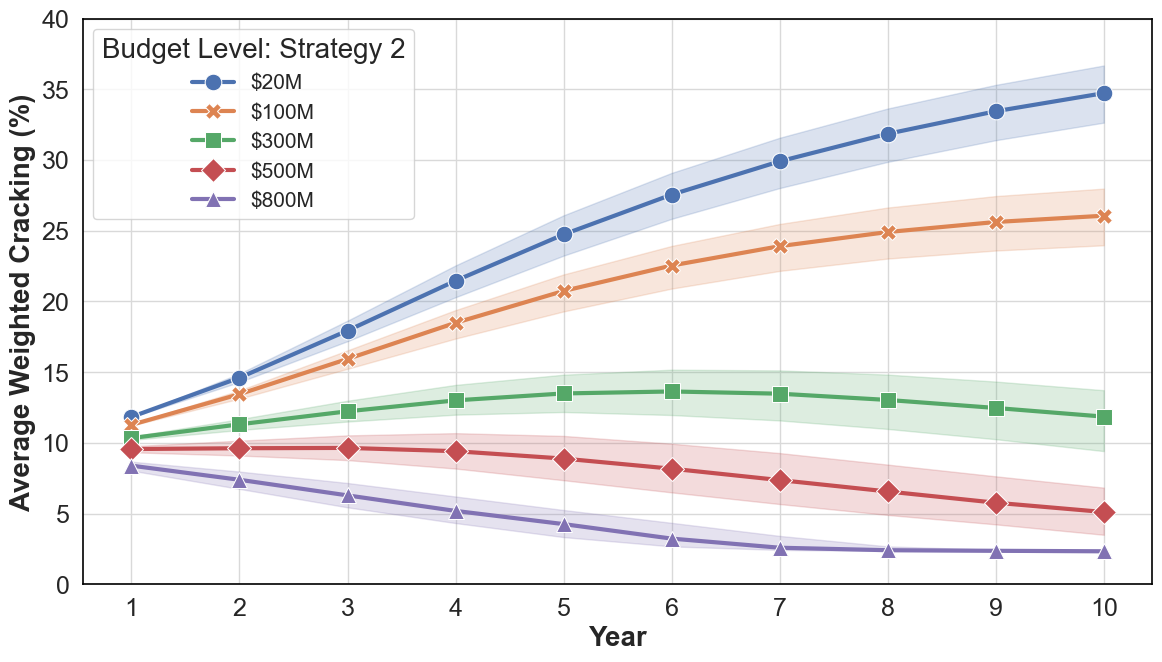

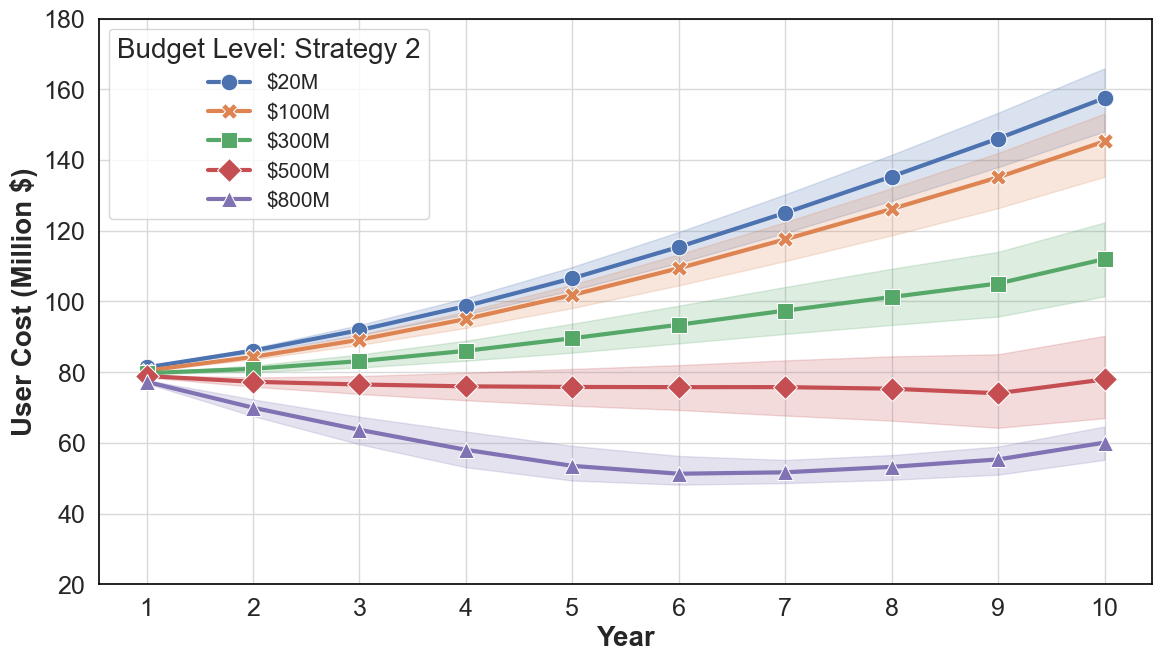


────────────────────────────────────────────────────────────
  Strategy 3 (COV = 0.15)
────────────────────────────────────────────────────────────


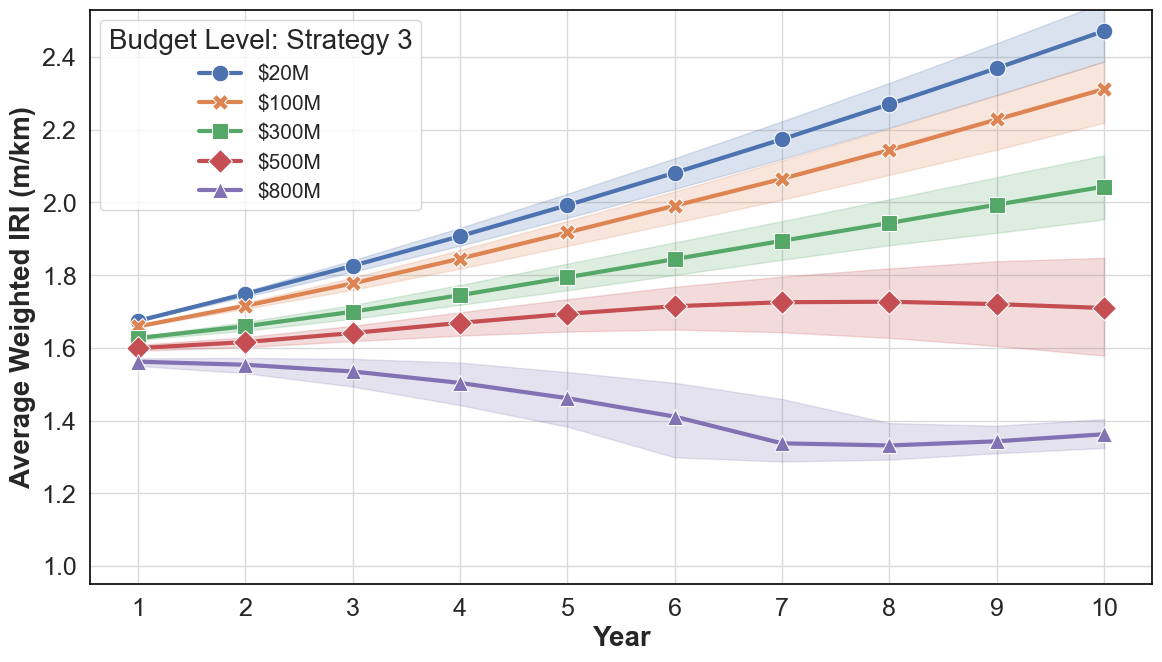

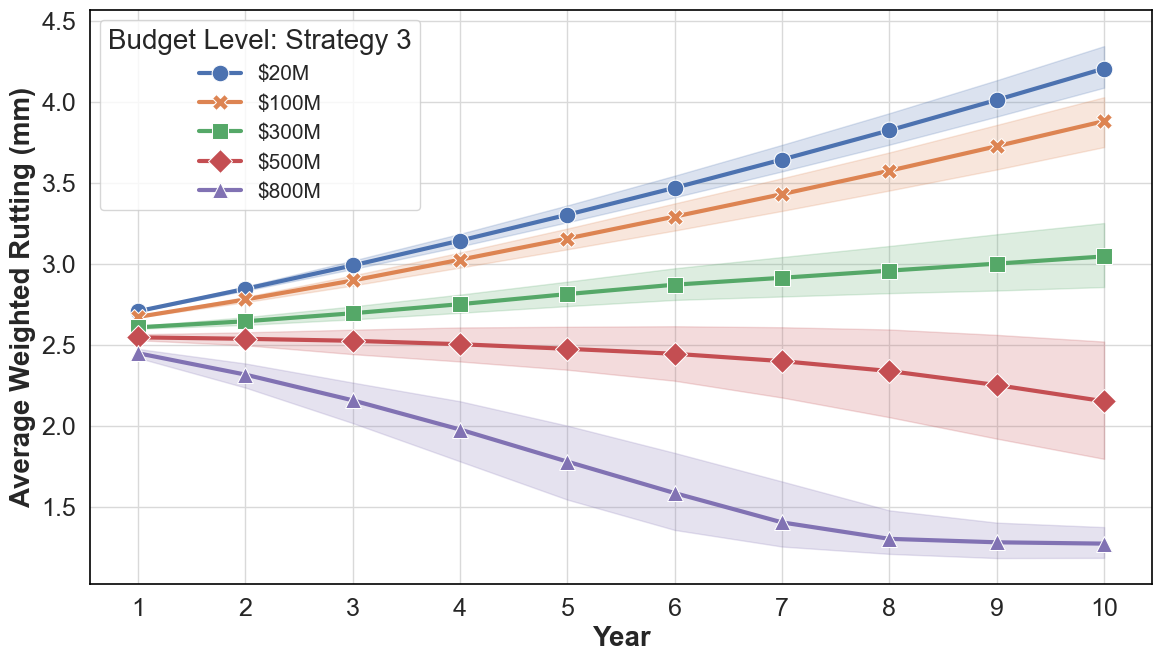

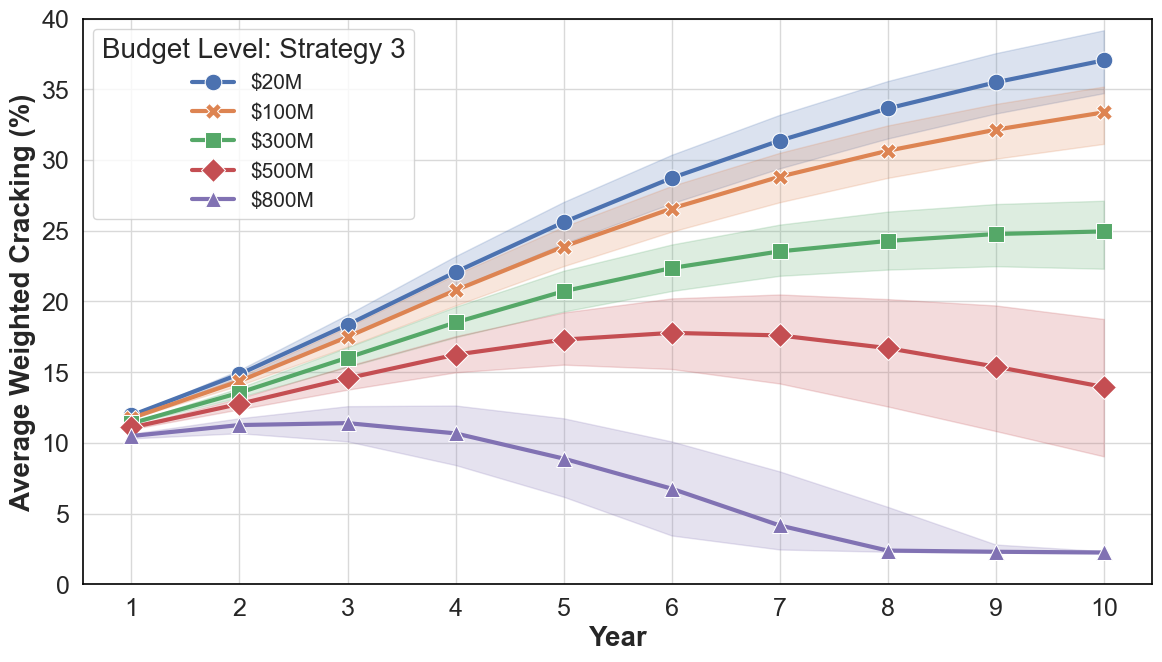

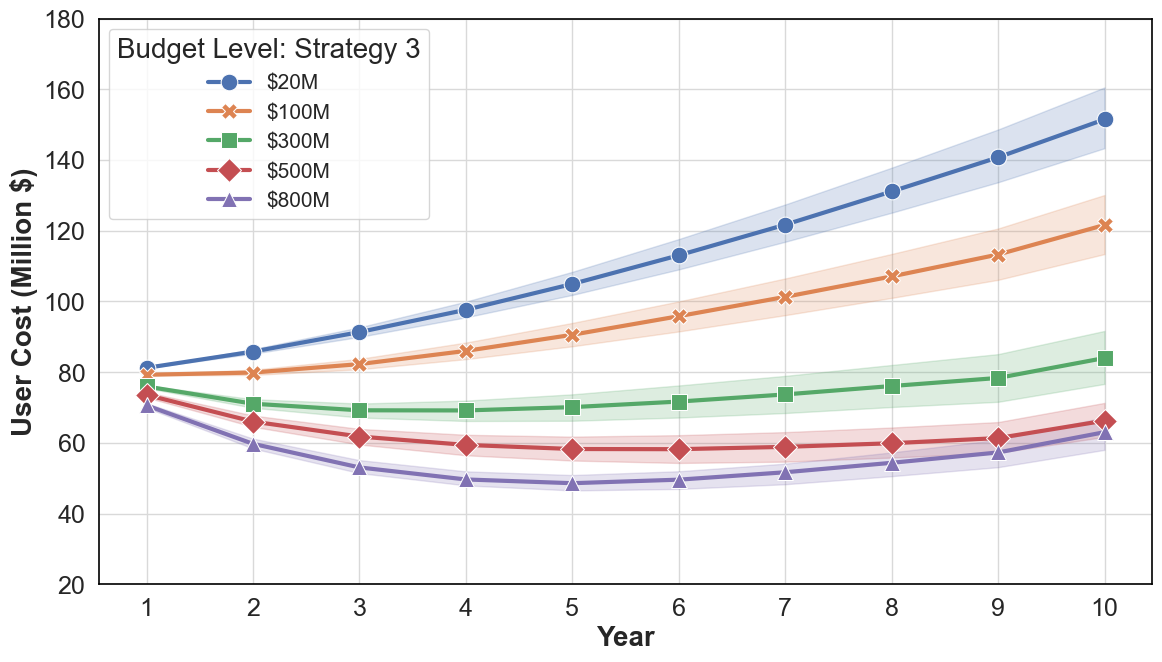


────────────────────────────────────────────────────────────
  Strategy 1 (COV = 0.15)
────────────────────────────────────────────────────────────


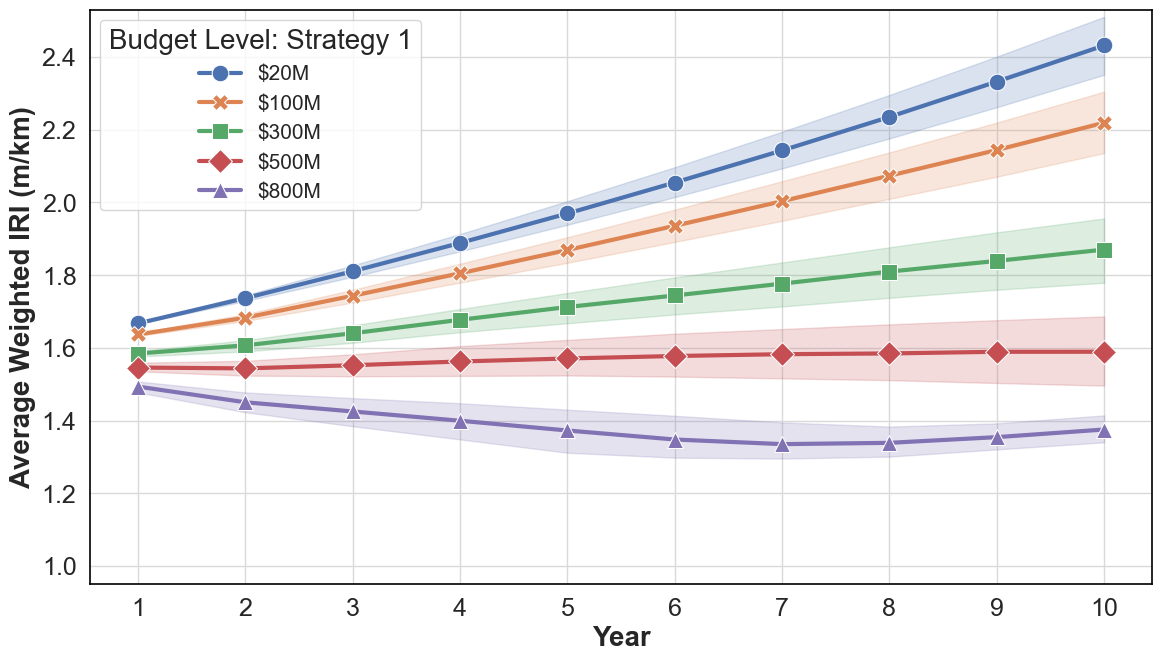

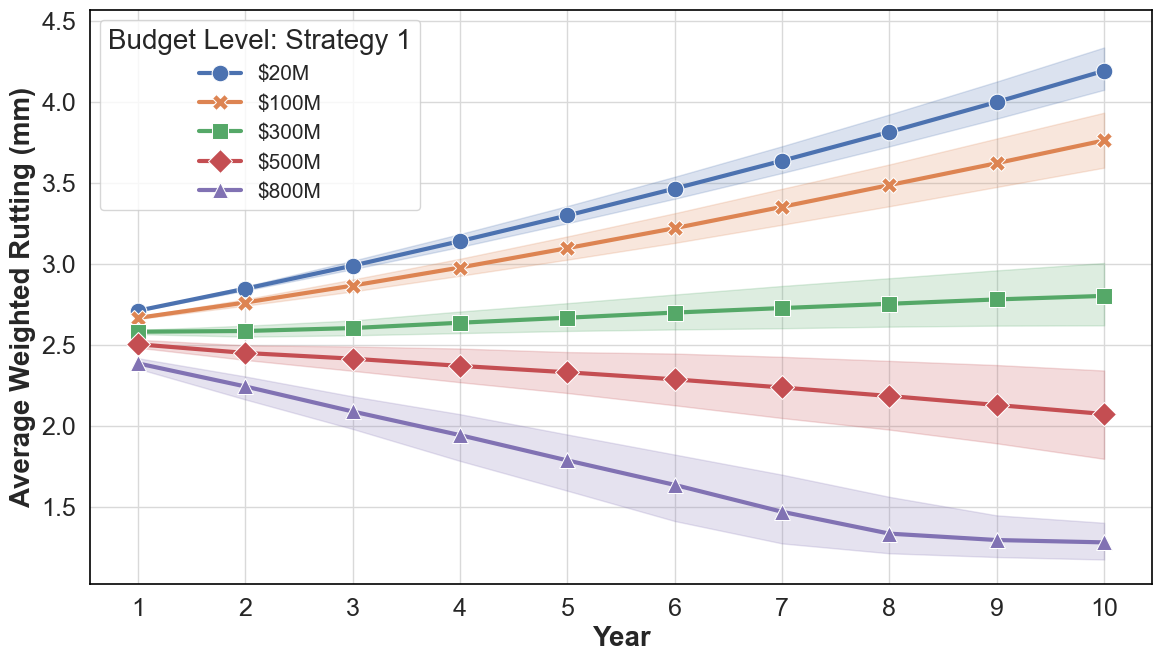

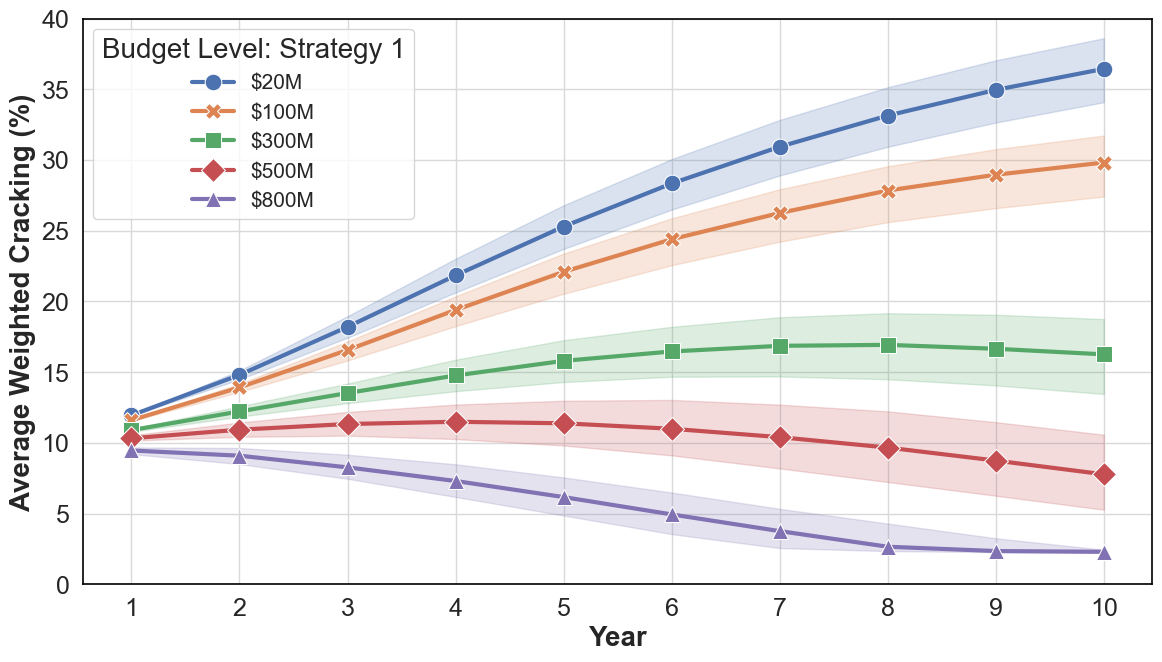

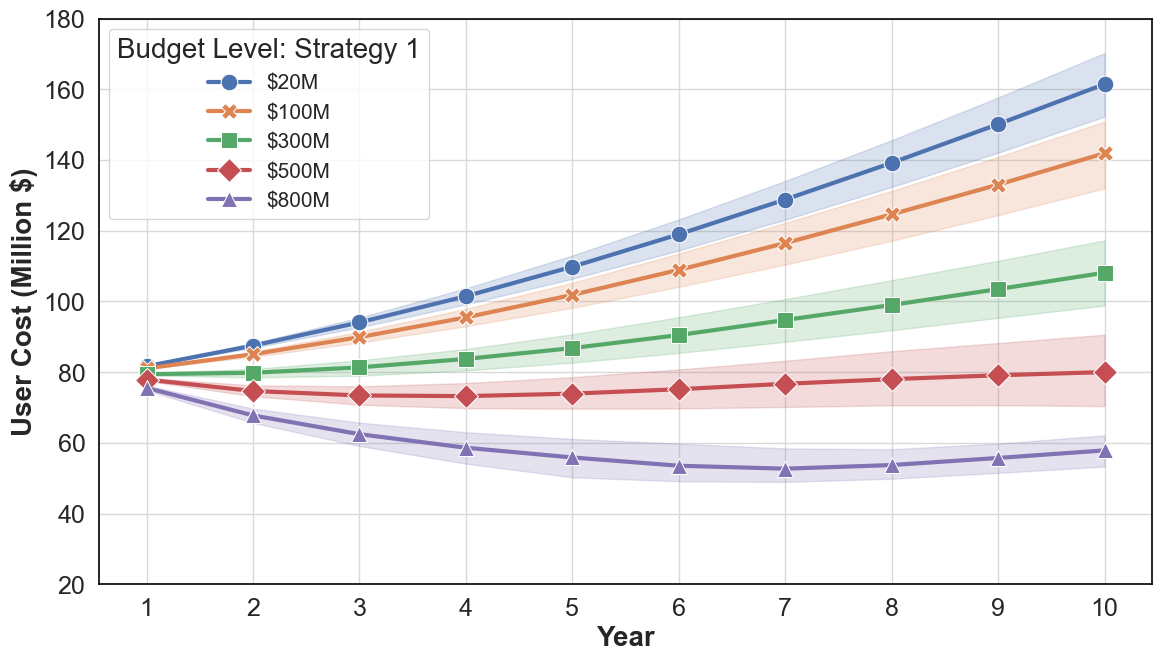

In [10]:
# ============================================================
# Scenario 2 – Multi-budget: IRI, Rutting, Cracking, User Cost (COV = 0.15)
# One figure per metric per strategy
# ============================================================

for strat_label, df_m in [
    ("Strategy 2",                   benefit_multi_s2),
    ("Strategy 3", benefitA_multi_s2),
    ("Strategy 1",                    worst_multi_s2),
]:
    print(f"\n{'─' * 60}\n  {strat_label} (COV = 0.15)\n{'─' * 60}")
    for metric_col, ylabel, ymin, ymax in METRICS_MULTI:
        plot_metric_by_budget(
            df=df_m,
            metric_col=metric_col,
            y_label=ylabel,
            y_min=ymin,
            y_max=ymax,
            legend_title=f"Budget Level: {strat_label}",
        )


## Reliability Analysis

Baseline network condition reliability, reported in the lane-mile weighted Good/Fair/Poor format used in state DOT pavement management reports (e.g. Minnesota DOT Table 1). This cell is self-contained: it imports its own libraries and reloads the 0.1-mile base GIS segments directly from disk, independent of any other cell in the notebook, so it can be run on its own.

Segments are grouped into three functional categories from the `Functional` field and weighted by `Lane_Miles`. Ratings use ADOT's existing `IRI_Rating`, `Cracking_R`, and `Rutting_Ra` fields — segments coded 0 (unrated) are excluded from that metric's percentage base. All thresholds are US customary units (not SI):

- **IRI:** Good < 95 in/mi, Fair 95-170 in/mi, Poor > 170 in/mi
- **Cracking:** Good < 5%, Fair 5-20%, Poor > 20%
- **Rutting:** Good < 0.2 in, Fair 0.2-0.4 in, Poor > 0.4 in


In [11]:
# ============================================================
# Reliability Analysis: Lane-Mile Weighted Condition Distribution
# by Functional Category (baseline GIS network, US customary units)
# Self-contained cell: own imports, own data load, no dependency on
# any other cell in this notebook.
# ============================================================

from pathlib import Path

import geopandas as gpd
import pandas as pd
from IPython.display import display

shapefile_path = Path("adot_data 2") / "gis" / "before_merge_0p1miles_arizona" / "Arizona.shp"

reliability_gdf = gpd.read_file(shapefile_path)  # 0.1-mile base segments, freshly loaded

RELIABILITY_FUNC_GROUPS = {
    "Freeways & Interstate": [1, 3, 11, 12],
    "Other Arterials": [2, 6, 14, 16],
    "Collectors & Local": [7, 8, 9, 17, 18, 19],
}
RELIABILITY_METRICS = {
    "IRI": "IRI_Rating",
    "Cracking": "Cracking_R",
    "Rutting": "Rutting_Ra",
}
RELIABILITY_RATING_LABELS = {1: "Good", 2: "Fair", 3: "Poor"}

total_lane_miles = reliability_gdf["Lane_Miles"].sum()

rows = []
for category, functional_codes in RELIABILITY_FUNC_GROUPS.items():
    subset = reliability_gdf[reliability_gdf["Functional"].isin(functional_codes)]
    network_share = subset["Lane_Miles"].sum() / total_lane_miles * 100

    row = {"Functional Category": category}
    for metric_label, rating_col in RELIABILITY_METRICS.items():
        rated = subset[subset[rating_col].isin(RELIABILITY_RATING_LABELS)]
        weighted = rated.groupby(rating_col)["Lane_Miles"].sum()
        weighted = weighted.reindex(RELIABILITY_RATING_LABELS, fill_value=0)
        pct = (weighted / weighted.sum() * 100).round(1)
        for code, label in RELIABILITY_RATING_LABELS.items():
            row[(metric_label, label)] = pct.loc[code]
    row[("Total Network", "")] = round(network_share, 1)
    rows.append(row)

reliability_table = pd.DataFrame(rows).set_index("Functional Category")
reliability_table.columns = pd.MultiIndex.from_tuples(reliability_table.columns)

print("Table. Lane-Mile Weighted Condition Distribution by Functional Category (Percentage) "
      "\u2013 Arizona Network")
print("Thresholds (US customary units): IRI Good <95 in/mi, Fair 95\u2013170 in/mi, Poor "
      ">170 in/mi | Cracking Good <5%, Fair 5\u201320%, Poor >20% | Rutting Good <0.2 in, "
      "Fair 0.2\u20130.4 in, Poor >0.4 in")
display(reliability_table)

Table. Lane-Mile Weighted Condition Distribution by Functional Category (Percentage) – Arizona Network
Thresholds (US customary units): IRI Good <95 in/mi, Fair 95–170 in/mi, Poor >170 in/mi | Cracking Good <5%, Fair 5–20%, Poor >20% | Rutting Good <0.2 in, Fair 0.2–0.4 in, Poor >0.4 in


IRI             Cracking             Rutting        \
                       Good  Fair  Poor     Good  Fair  Poor    Good  Fair   
Functional Category                                                          
Freeways & Interstate  82.5  14.8   2.7     63.5  23.0  13.5    88.2  11.3   
Arterials              42.4  41.1  16.5     39.7  33.0  27.3    85.6  13.6   
Collectors & Local     33.3  44.2  22.6     37.9  35.0  27.1    92.5   7.0   

                           Total Network  
                      Poor                
Functional Category                       
Freeways & Interstate  0.5          28.5  
Arterials              0.8          45.1  
Collectors & Local     0.6          26.5

### State of Good Repair (SOGR) Reliability Analysis

Scope: **Budget = $440,000,000**, four functional groups, using the Monte Carlo simulations already computed per strategy under `segment_results/strategy=.../budget=440000000/`. Requires the `AADT` column added to `segments_cov0.15.parquet` by the one-time data-prep cell in `Arizona_Case_Study_Stochastic.ipynb`.

| Group | Functional codes | Fail rule |
|---|---|---|
| Freeways & Interstate | 1, 3, 11, 12 | SOGR >= 2% |
| Other Arterials | 2, 6, 14, 16 | SOGR >= 7% |
| Collectors | 7, 8, 17, 18 | SOGR >= 7% |
| Rural (Local) | 9, 19 | Split by AADT: fails if High-AADT (>400) sub-SOGR >= 7% **OR** Low-AADT (<=400) sub-SOGR >= 15% |

For the Rural group, the reported Mean SOGR is the blended value across both AADT tiers combined (same weighting as if AADT weren't split); only the Pass/Fail decision uses the two AADT-tiered sub-SOGRs and thresholds.


In [12]:
# ============================================================
# State of Good Repair (SOGR) Reliability Analysis
# Four functional groups, Budget = $440,000,000
# Self-contained cell: own imports, own data load, no dependency on
# any other cell in this notebook. Requires AADT in segments_cov0.15.parquet
# (see the one-time data-prep cell above).
# ============================================================

import glob

import numpy as np
import pandas as pd
from IPython.display import display

SOGR_BUDGET = 440_000_000
SOGR_YEARS = 10
SOGR_STRATEGIES = ["worst_first", "preservation", "preservation_aadt"]
SOGR_RESULTS_DIR = "segment_results"

SOGR_FUNCTIONAL_GROUPS = {
    "Freeways & Interstate": {"codes": [1, 3, 11, 12], "fail_threshold_pct": 2.0},
    "Other Arterials": {"codes": [2, 6, 14, 16], "fail_threshold_pct": 7.0},
    "Collectors": {"codes": [7, 8, 17, 18], "fail_threshold_pct": 7.0},
}
SOGR_RURAL_CODES = [9, 19]
SOGR_RURAL_AADT_SPLIT = 400
SOGR_RURAL_HIGH_AADT_THRESHOLD_PCT = 7.0
SOGR_RURAL_LOW_AADT_THRESHOLD_PCT = 15.0
SOGR_GROUP_ORDER = ["Freeways & Interstate", "Other Arterials", "Collectors", "Rural"]

segments = pd.read_parquet(f"{SOGR_RESULTS_DIR}/segments_cov0.15.parquet")
segment_lookup = segments[["segment_id", "Functional", "lane_miles_cal", "AADT"]]


def _rate(values, good_max, fair_max):
    """Good if <= good_max, Fair if <= fair_max, else Poor."""
    return np.select([values <= good_max, values <= fair_max], ["Good", "Fair"], default="Poor")


def _overall_condition(iri_rating, cracking_rating, rutting_rating):
    """All 3 Good -> Good; 2+ Poor -> Poor; anything else -> Fair."""
    poor_count = (
        (iri_rating == "Poor").astype(int)
        + (cracking_rating == "Poor").astype(int)
        + (rutting_rating == "Poor").astype(int)
    )
    all_good = (iri_rating == "Good") & (cracking_rating == "Good") & (rutting_rating == "Good")
    return np.where(all_good, "Good", np.where(poor_count >= 2, "Poor", "Fair"))


def _weighted_poor_pct(weight, is_poor):
    """Lane-mile-weighted % of segments with Overall = Poor; 0 if the group is empty."""
    total = weight.sum()
    if total <= 0:
        return 0.0
    return weight[is_poor].sum() / total * 100


sogr_records = []
for strategy in SOGR_STRATEGIES:
    sim_files = sorted(glob.glob(
        f"{SOGR_RESULTS_DIR}/strategy={strategy}/budget={SOGR_BUDGET}/simulation=*.parquet"
    ))
    for sim_file in sim_files:
        sim_df = pd.read_parquet(sim_file).merge(segment_lookup, on="segment_id", how="inner")
        simulation_id = sim_df["simulation"].iloc[0]
        functional = sim_df["Functional"].to_numpy()
        lane_miles = sim_df["lane_miles_cal"].to_numpy()
        aadt = sim_df["AADT"].to_numpy()

        for year in range(SOGR_YEARS):
            iri_rating = _rate(sim_df[f"iri_y{year}"].to_numpy(), 95, 170)
            cracking_rating = _rate(sim_df[f"cracking_y{year}"].to_numpy(), 5, 20)
            rutting_rating = _rate(sim_df[f"rutting_y{year}"].to_numpy(), 0.2, 0.4)
            is_poor = _overall_condition(iri_rating, cracking_rating, rutting_rating) == "Poor"

            for group_name, group_info in SOGR_FUNCTIONAL_GROUPS.items():
                mask = np.isin(functional, group_info["codes"])
                sogr_pct = _weighted_poor_pct(lane_miles[mask], is_poor[mask])
                sogr_records.append({
                    "functional_group": group_name,
                    "strategy": strategy,
                    "simulation": simulation_id,
                    "year": year,
                    "sogr_poor_pct": sogr_pct,
                    "fail": sogr_pct >= group_info["fail_threshold_pct"],
                })

            rural_mask = np.isin(functional, SOGR_RURAL_CODES)
            high_aadt_mask = rural_mask & (aadt > SOGR_RURAL_AADT_SPLIT)
            low_aadt_mask = rural_mask & (aadt <= SOGR_RURAL_AADT_SPLIT)

            sogr_high = _weighted_poor_pct(lane_miles[high_aadt_mask], is_poor[high_aadt_mask])
            sogr_low = _weighted_poor_pct(lane_miles[low_aadt_mask], is_poor[low_aadt_mask])
            sogr_blended = _weighted_poor_pct(lane_miles[rural_mask], is_poor[rural_mask])

            rural_fail = (
                (sogr_high >= SOGR_RURAL_HIGH_AADT_THRESHOLD_PCT)
                or (sogr_low >= SOGR_RURAL_LOW_AADT_THRESHOLD_PCT)
            )

            sogr_records.append({
                "functional_group": "Rural",
                "strategy": strategy,
                "simulation": simulation_id,
                "year": year,
                "sogr_poor_pct": sogr_blended,
                "fail": rural_fail,
            })

sogr_df = pd.DataFrame(sogr_records)

failure_probability = (
    sogr_df.groupby(["functional_group", "strategy", "year"])["fail"]
    .mean()
    .unstack("strategy")
    .reindex(columns=SOGR_STRATEGIES)
)
mean_sogr = (
    sogr_df.groupby(["functional_group", "strategy", "year"])["sogr_poor_pct"]
    .mean()
    .unstack("strategy")
    .reindex(columns=SOGR_STRATEGIES)
)

for group_name in SOGR_GROUP_ORDER:
    print(f"SOGR reliability \u2014 {group_name}, Budget = ${SOGR_BUDGET:,}")
    print("Probability of failure by year:")
    display(failure_probability.loc[group_name].round(3))
    print("Mean SOGR (%) by year:")
    display(mean_sogr.loc[group_name].round(2))
    print()

SOGR reliability — Freeways & Interstate, Budget = $440,000,000
Probability of failure by year:


strategy,worst_first,preservation,preservation_aadt
year,,,
0,0.000,0.000,0.000
1,0.000,0.000,0.000
2,0.000,0.000,0.000
3,0.000,0.043,0.000
4,0.000,0.319,0.027
5,0.010,0.425,0.040
6,0.053,0.485,0.037
7,0.123,0.558,0.043
8,0.183,0.628,0.080


Mean SOGR (%) by year:


strategy,worst_first,preservation,preservation_aadt
year,,,
0,1.00,1.19,1.11
1,0.96,1.38,1.17
2,1.00,1.52,1.22
3,1.06,1.66,1.22
4,1.16,1.78,1.20
5,1.27,1.90,1.21
6,1.39,2.02,1.26
7,1.45,2.13,1.36
8,1.50,2.25,1.52



SOGR reliability — Arterials, Budget = $440,000,000
Probability of failure by year:


...

strategy,worst_first,preservation,preservation_aadt
year,,,
0,3.71,3.24,8.58
1,3.90,2.78,10.69
2,4.41,2.59,12.59
3,4.86,2.41,14.64
4,4.98,2.16,16.57
5,4.90,1.96,18.48
6,4.76,1.80,20.31
7,4.58,1.64,22.00
8,4.36,1.48,23.41



SOGR reliability — Rural, Budget = $440,000,000
Probability of failure by year:


strategy,worst_first,preservation,preservation_aadt
year,,,
0,0.000,0.000,1.000
1,0.000,0.000,1.000
2,0.066,0.010,1.000
3,0.279,0.040,0.997
4,0.482,0.050,0.993
5,0.399,0.013,0.993
6,0.256,0.007,0.990
7,0.199,0.003,0.990
8,0.169,0.003,0.987


Mean SOGR (%) by year:


strategy,worst_first,preservation,preservation_aadt
year,,,
0,4.11,4.59,9.62
1,4.52,3.87,12.03
2,5.53,4.12,14.14
3,5.98,3.88,15.42
4,6.22,3.44,16.42
5,5.91,3.00,16.82
6,5.47,2.71,16.81
7,5.08,2.44,16.51
8,4.62,2.08,15.92


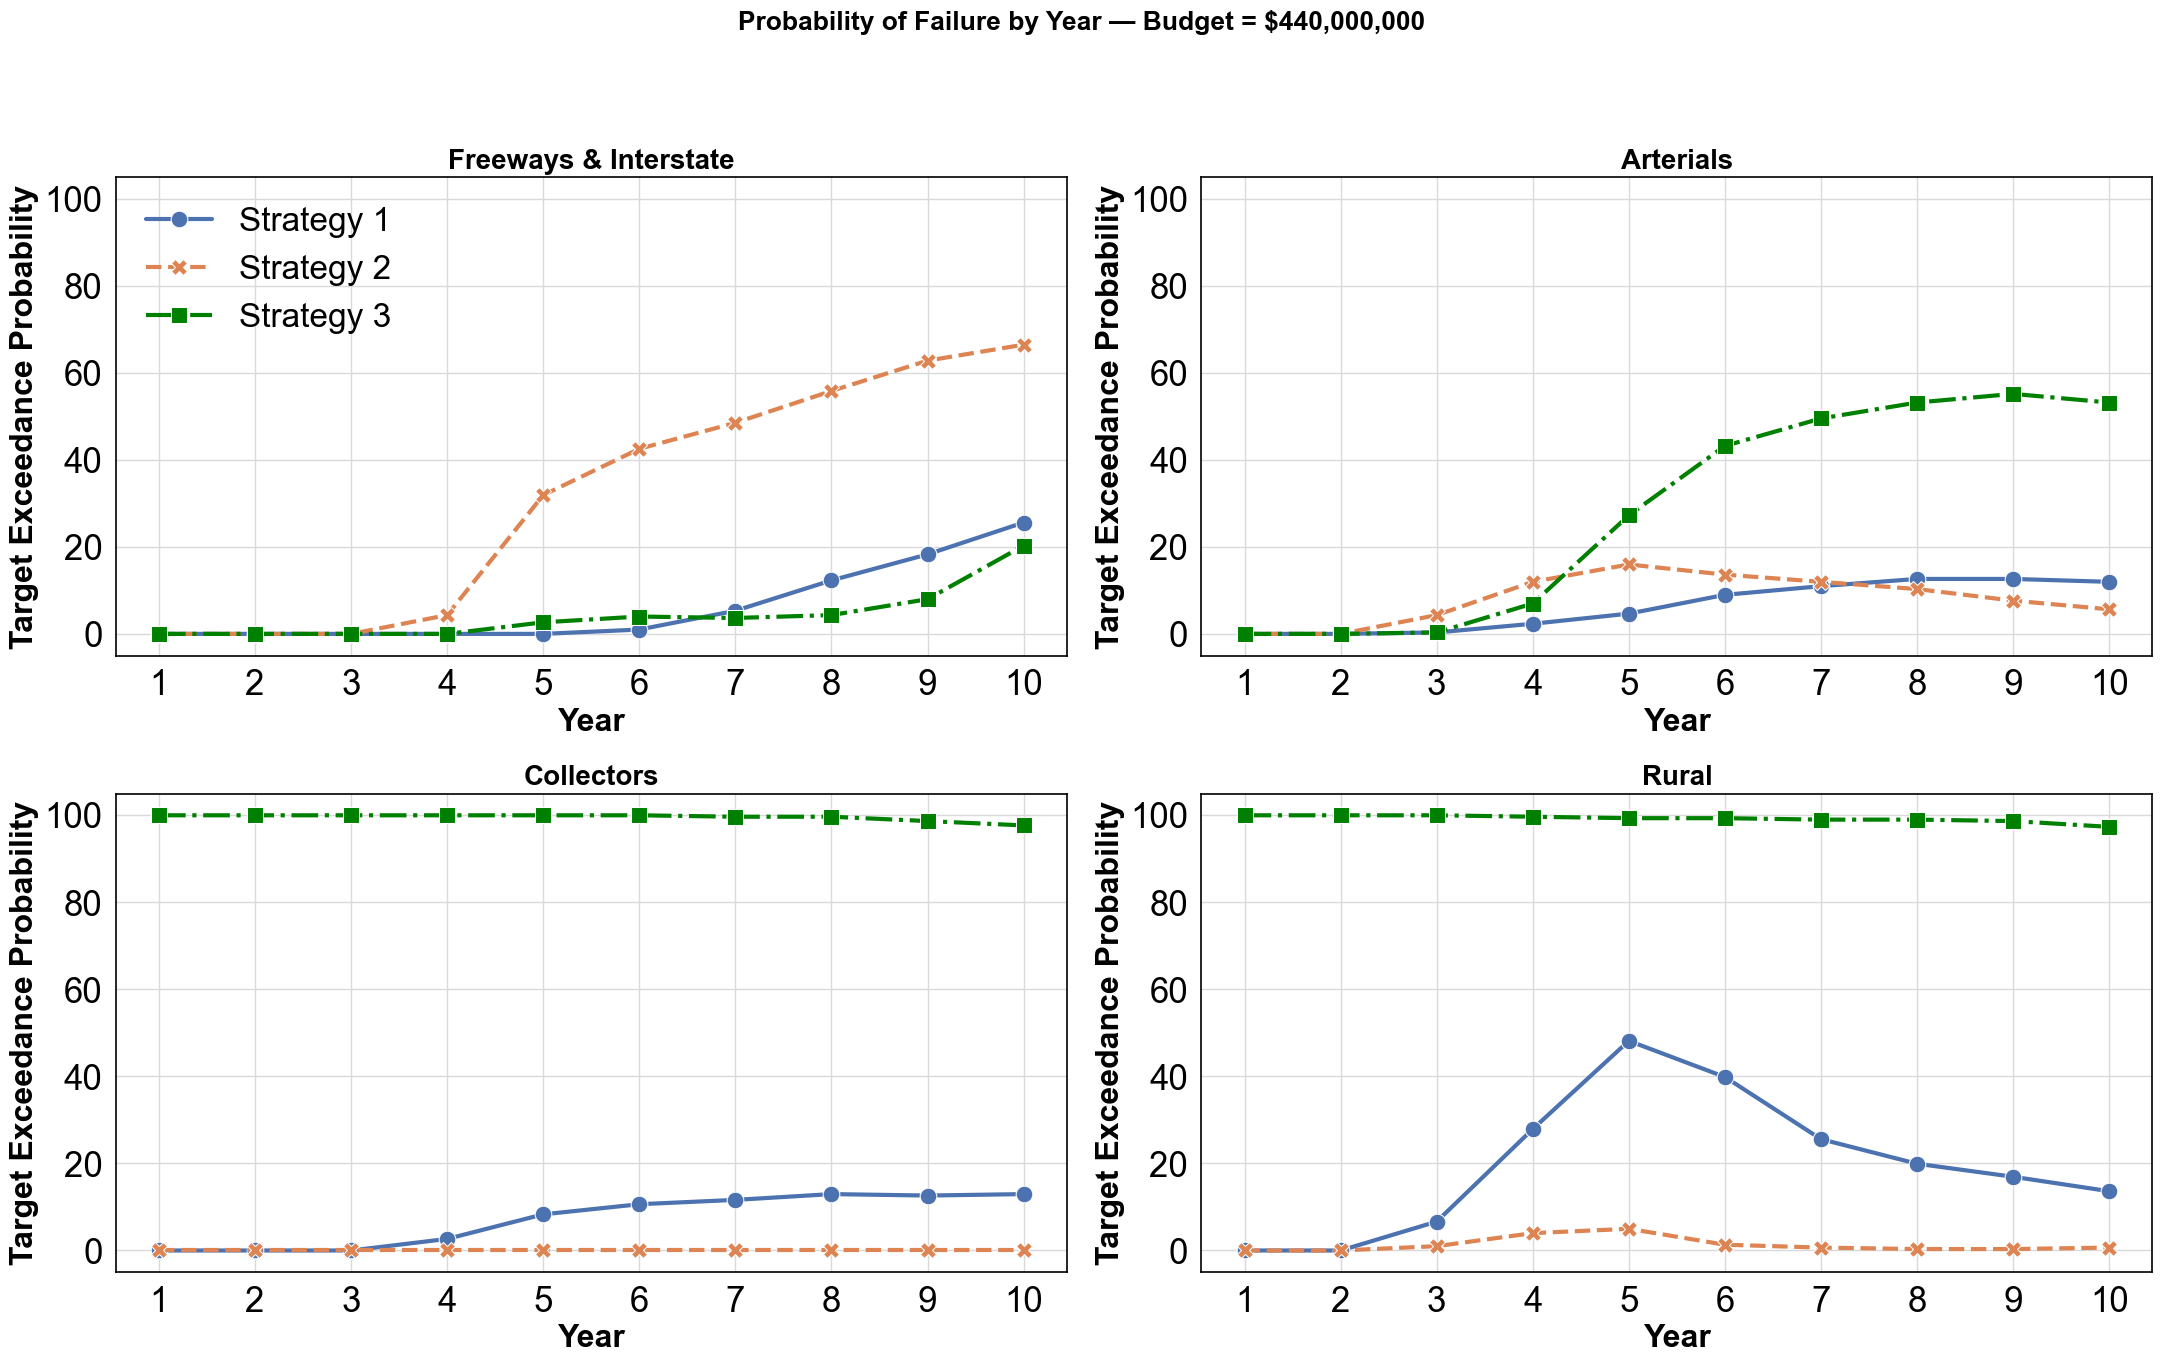

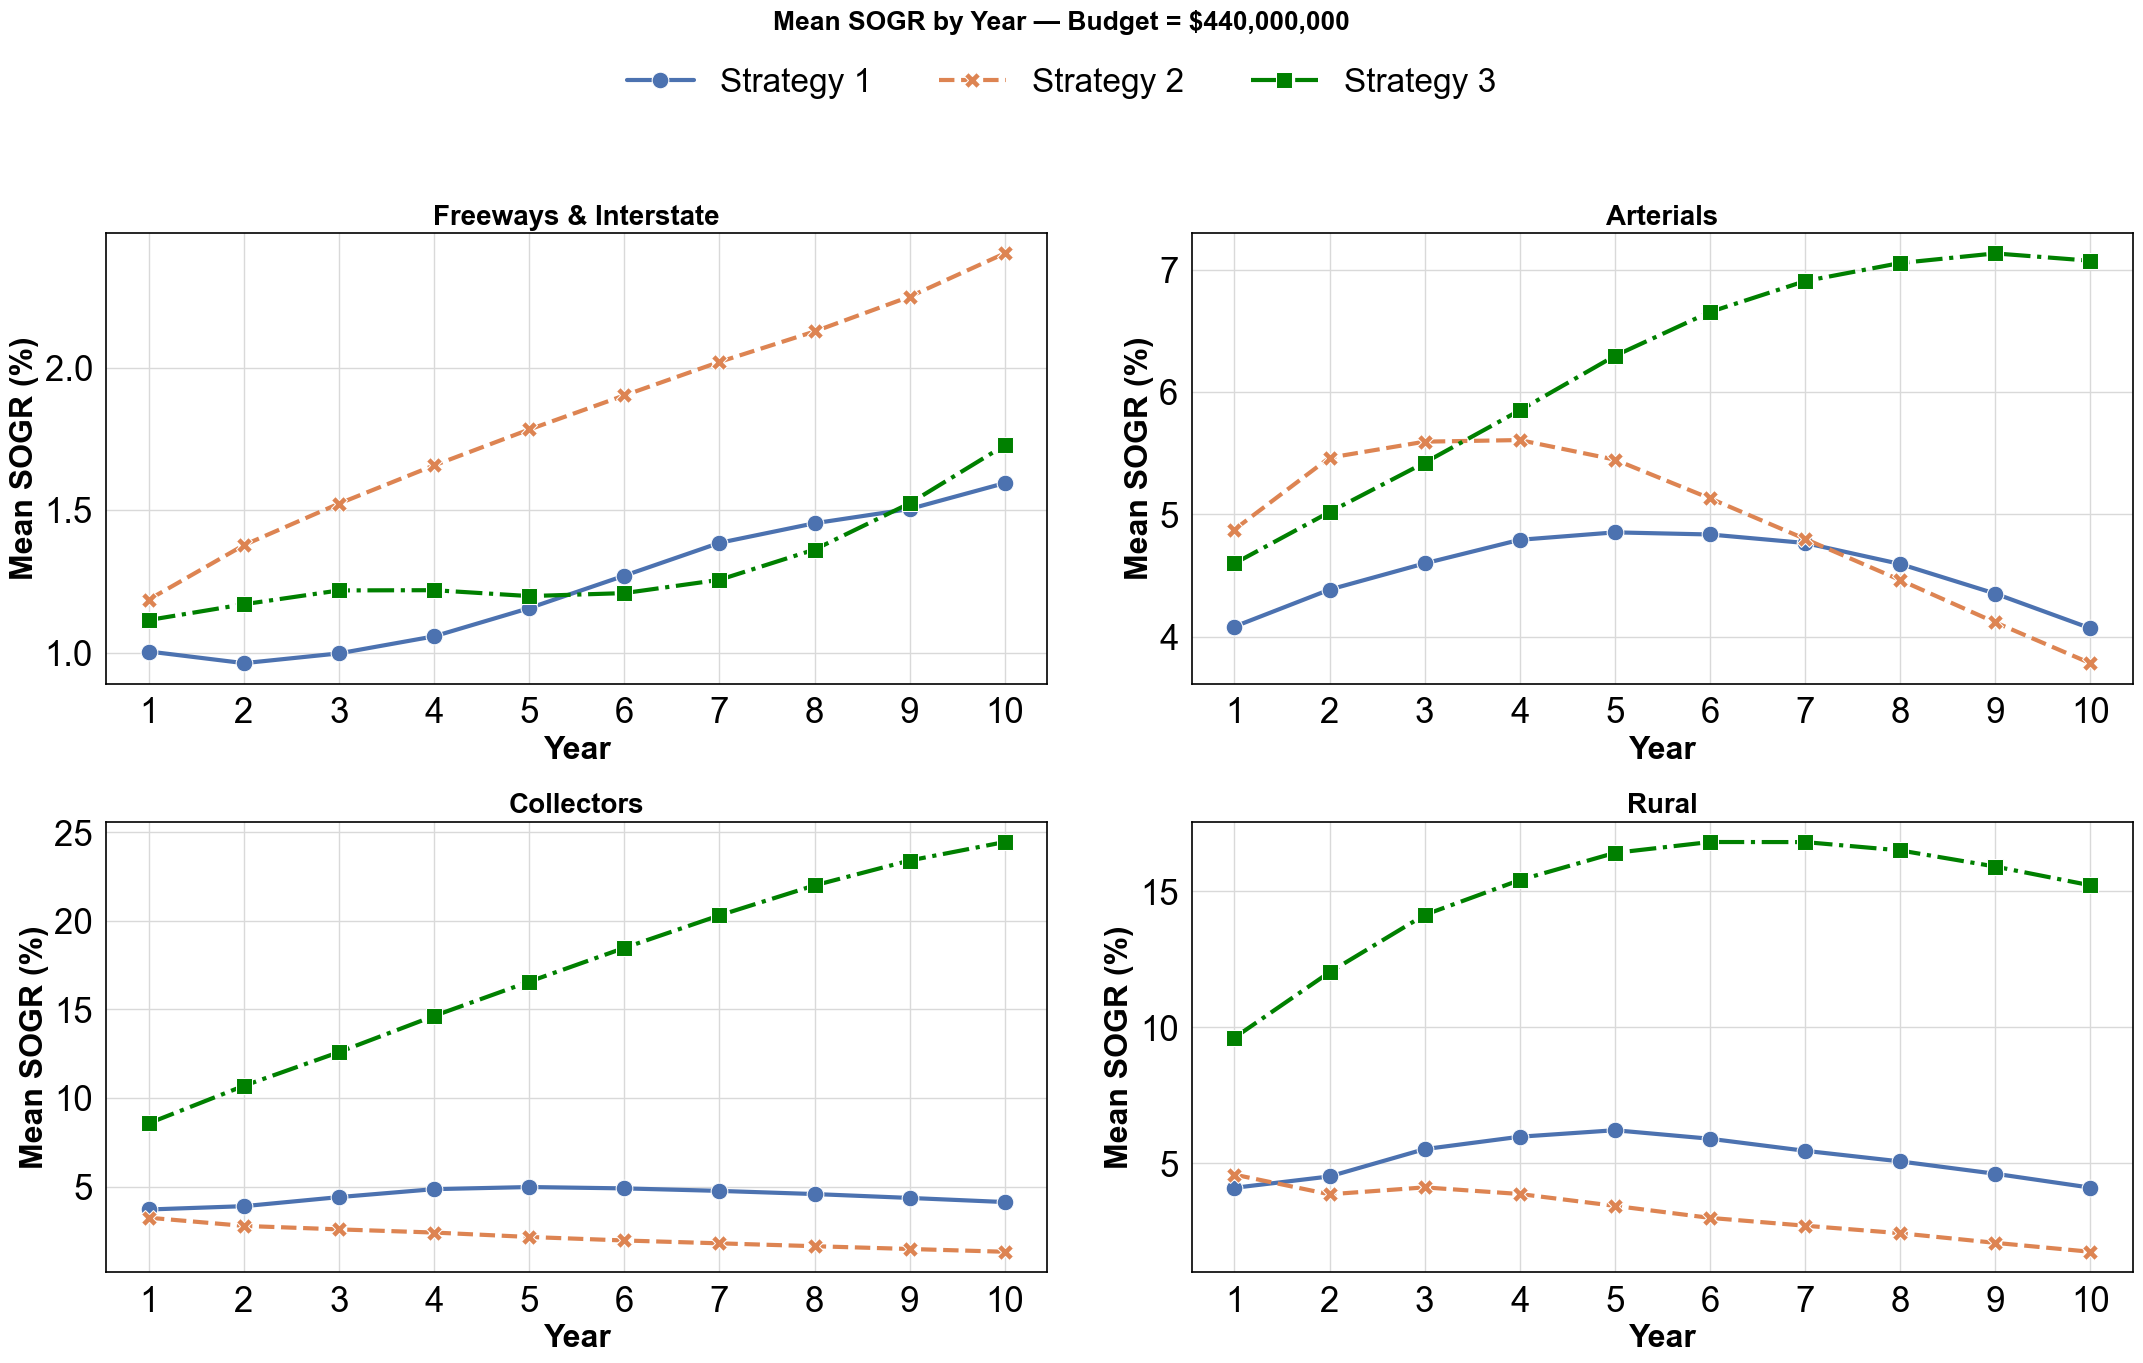

In [20]:
# ============================================================
# SOGR Reliability Plots: Probability of Failure & Mean SOGR
# One combined figure per metric, 2x2 subplot grid (one panel per
# functional group), shared legend, Year labeled 1-10.
# Uses failure_probability, mean_sogr, SOGR_GROUP_ORDER,
# SOGR_STRATEGIES, SOGR_YEARS, SOGR_BUDGET from the previous cell.
# Self-contained styling constants, matching the notebook-wide
# 2x2 plot convention (fontsize/figsize/linewidth/markersize).
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

palette = sns.color_palette("deep")

SOGR_STRATEGY_STYLE = {
    "worst_first": {"color": palette[0], "marker": "o", "linestyle": "-", "label": "Strategy 1"},
    "preservation": {"color": palette[1], "marker": "X", "linestyle": "--", "label": "Strategy 2"},
    "preservation_aadt": {"color": "green", "marker": "s", "linestyle": "-.", "label": "Strategy 3"},
}

SOGR_FIGSIZE = (22, 14)
SOGR_LINEWIDTH = 3
SOGR_MARKERSIZE = 12
SOGR_LABEL_FONTSIZE = 23
SOGR_TICK_FONTSIZE = 25
SOGR_TITLE_FONTSIZE = 20
SOGR_SUPTITLE_FONTSIZE = 19
SOGR_LEGEND_FONTSIZE = 24

sogr_years = list(range(SOGR_YEARS))
sogr_year_labels = [year + 1 for year in sogr_years]  # display Year 1-10

def _plot_sogr_grid(table, ylabel, suptitle, ylim=None, yticks=None, legend_in_first_panel=False):
    fig, axes = plt.subplots(2, 2, figsize=SOGR_FIGSIZE)
    axes_flat = axes.flatten()
    handles, labels = None, None

    for ax, group_name in zip(axes_flat, SOGR_GROUP_ORDER):
        for strategy in SOGR_STRATEGIES:
            style = SOGR_STRATEGY_STYLE[strategy]
            values = table.loc[group_name][strategy].reindex(sogr_years)
            sns.lineplot(
                x=sogr_year_labels, y=values, ax=ax,
                color=style["color"],
                marker=style["marker"],
                linestyle=style["linestyle"],
                markersize=SOGR_MARKERSIZE,
                linewidth=SOGR_LINEWIDTH,
                label=style["label"],
                estimator=None, errorbar=None, sort=False, legend=False,
            )
        ax.set_title(group_name, fontsize=SOGR_TITLE_FONTSIZE, fontweight="bold", color="black")
        ax.set_xlabel("Year", fontsize=SOGR_LABEL_FONTSIZE, fontweight="bold", color="black")
        ax.set_ylabel(ylabel, fontsize=SOGR_LABEL_FONTSIZE, fontweight="bold", color="black")
        ax.set_xticks(sogr_year_labels)
        ax.tick_params(axis="both", labelsize=SOGR_TICK_FONTSIZE, colors="black")
        if ylim is not None:
            ax.set_ylim(*ylim)
        if yticks is not None:
            ax.set_yticks(yticks)
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    fig.suptitle(suptitle, fontsize=SOGR_SUPTITLE_FONTSIZE, fontweight="bold", color="black")
    legend_kwargs = dict(
        fontsize=SOGR_LEGEND_FONTSIZE,
        frameon=False,       # no legend box
        labelcolor="black",
        # facecolor not needed as frameon=False
        # edgecolor not needed as frameon=False
    )
    if legend_in_first_panel:
        axes_flat[0].legend(loc="upper left", **legend_kwargs)
        plt.tight_layout(rect=[0, 0, 1, 0.94])
    else:
        fig.legend(
            handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.96),
            ncol=3, **legend_kwargs
        )
        plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

_plot_sogr_grid(
    failure_probability * 100,
    ylabel="Target Exceedance Probability",
    suptitle=f"Probability of Failure by Year \u2014 Budget = ${SOGR_BUDGET:,}",
    ylim=(-5, 105),
    yticks=range(0, 101, 20),
    legend_in_first_panel=True,
)

_plot_sogr_grid(
    mean_sogr,
    ylabel="Mean SOGR (%)",
    suptitle=f"Mean SOGR by Year \u2014 Budget = ${SOGR_BUDGET:,}",
)

## Sensitivity


Plot saved -> C:\Users\mzeigham\OneDrive - University of Massachusetts\Education\UMass\Research\FHWA\Code\code-Segmentation-5miles\Sensitivity\sensitivity_iri_year10_worst-first.png


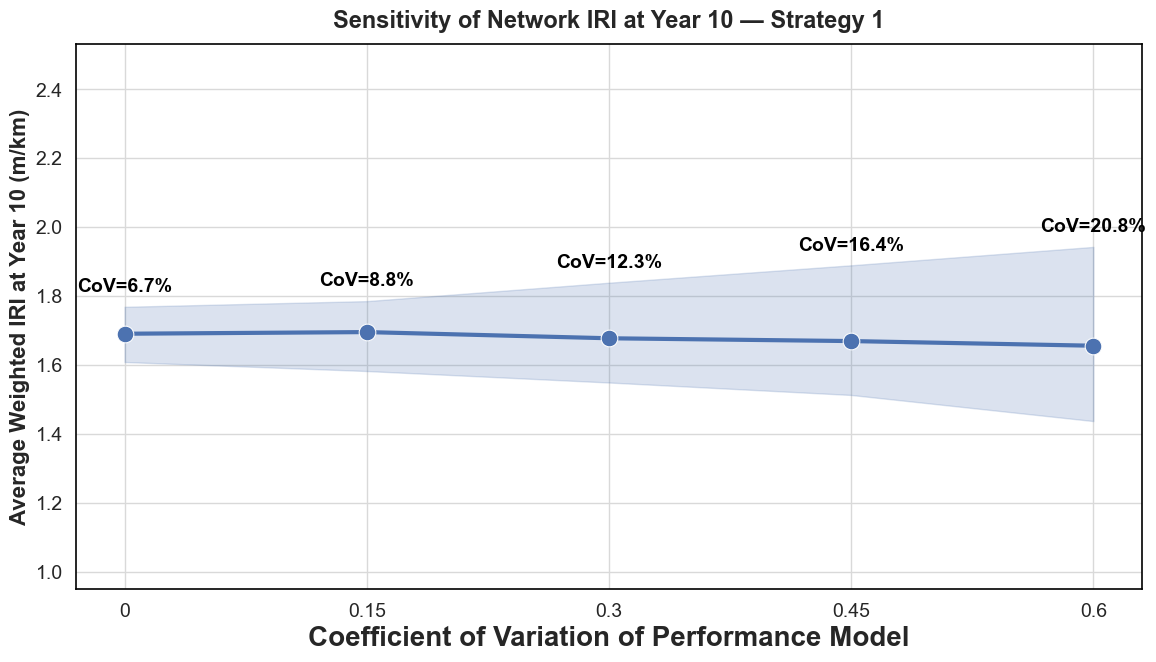

Plot saved -> C:\Users\mzeigham\OneDrive - University of Massachusetts\Education\UMass\Research\FHWA\Code\code-Segmentation-5miles\Sensitivity\sensitivity_iri_year10_preservation.png


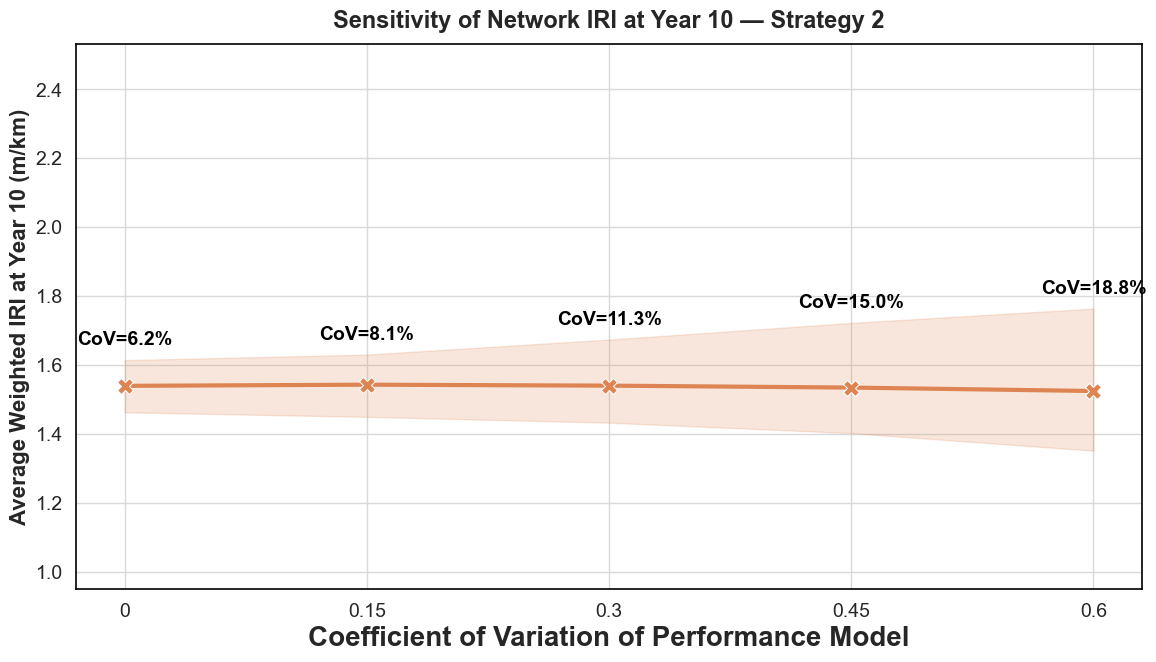

Plot saved -> C:\Users\mzeigham\OneDrive - University of Massachusetts\Education\UMass\Research\FHWA\Code\code-Segmentation-5miles\Sensitivity\sensitivity_iri_year10_preservation_aadt.png


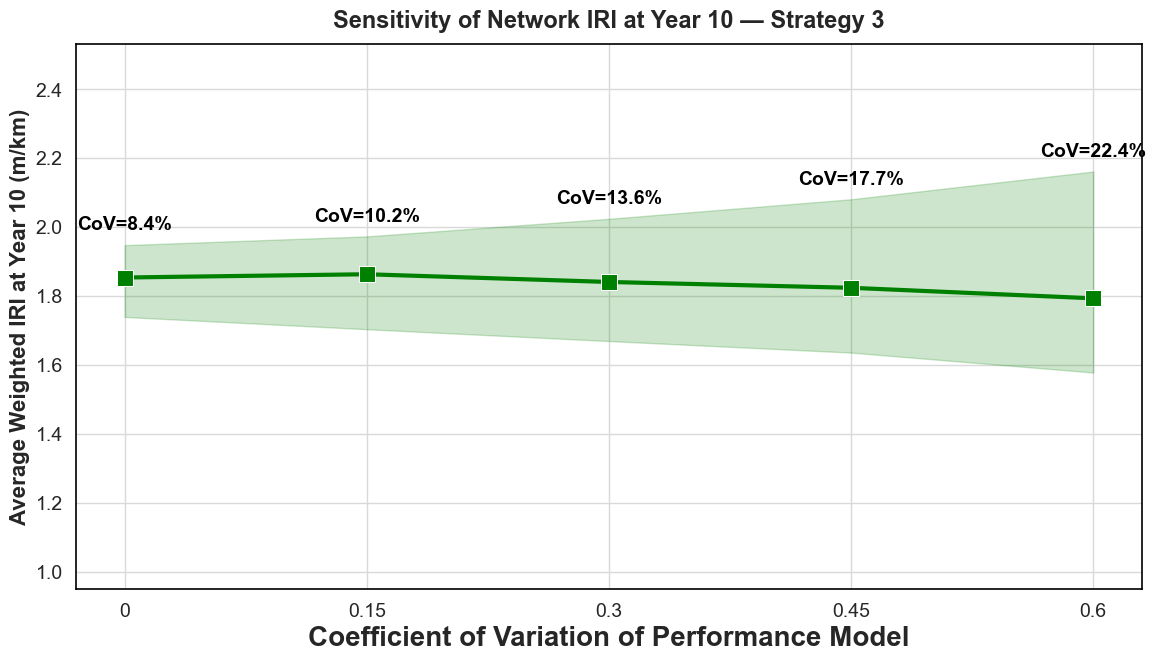

strategy,Strategy 1,Strategy 2,Strategy 3
Coefficient of Variation,,,
0.00,1.690787,1.539724,1.853767
0.15,1.695556,1.543057,1.863260
0.30,1.677622,1.540322,1.840875
0.45,1.669521,1.534692,1.823982
0.60,1.656013,1.524734,1.793418


In [14]:
# ============================================================
# Sensitivity Analysis: IRI at Year 10 vs. Performance-Model CoV
# Scope  : Single-budget, all three strategies -- one figure per strategy
# X-axis : CoV of the performance model (0, 0.15, 0.30, 0.45, 0.60)
# Y-axis : Average Weighted IRI at year 10 (m/km)
#          (median line + P25/P75 band; output CoV% annotated in black per point)
# ============================================================

import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ============================================================
# Plotting constants
# ============================================================
sns.set_theme(style="whitegrid", font_scale=1.6, rc={"axes.edgecolor": "black", "axes.linewidth": 1.2, "grid.color": "0.85"})

LINEWIDTH       = 3
MARKERSIZE      = 12
BAND_ALPHA      = 0.20
PERCENTILE_BAND = (25, 75)

palette = sns.color_palette("deep")

STRATEGY_STYLES = {
    "Worst-first": {
        "color":  palette[0],
        "marker": "o",
        "label":  "Strategy 1",
        "file":   "single_budget_simulation_worstfirst_cov{cov}.csv",
    },
    "Preservation": {
        "color":  palette[1],
        "marker": "X",
        "label":  "Strategy 2",
        "file":   "single_budget_simulation_benefit_cov{cov}.csv",
    },
    "Preservation_AADT": {
        "color":  "green",
        "marker": "s",
        "label":  "Strategy 3",
        "file":   "single_budget_simulation_benefit_aadt_cov{cov}.csv",
    },
}

# ============================================================
# Data location
# ============================================================
BASE_PATH       = pathlib.Path("Sensitivity")
COV_VALUES_FILE = [0.0001, 0.15, 0.30, 0.45, 0.60]   # actual values in file names
COV_VALUES_PLOT = [0,      0.15, 0.30, 0.45, 0.60]   # displayed on x-axis (0.0001 → 0)
TARGET_YEAR     = 10
METRIC_COL      = "weighted_avg_iri"
YLABEL          = "Average Weighted IRI at Year 10 (m/km)"
# SI unit conversion: IRI is stored in in/mi (US customary); 1 in/mi = 0.0157828 m/km.
IRI_IN_MI_TO_M_KM = 0.0157828

# ============================================================
# Summary builder (median + P25/P75 + output CoV%, for annotations)
# ============================================================
def build_summary(strategy_key):
    style  = STRATEGY_STYLES[strategy_key]
    lo, hi = PERCENTILE_BAND
    records = []

    for cov_file, cov_plot in zip(COV_VALUES_FILE, COV_VALUES_PLOT):
        fname = BASE_PATH / style["file"].format(cov=cov_file)
        if not fname.exists():
            print(f"[WARNING] Missing: {fname.name} — skipped")
            continue

        df   = pd.read_csv(fname)
        vals = df[df["year"] == TARGET_YEAR][METRIC_COL] * IRI_IN_MI_TO_M_KM

        if vals.empty:
            print(f"[WARNING] Year {TARGET_YEAR} not found in {fname.name} — skipped")
            continue

        mean_val = float(vals.mean())
        std_val  = float(vals.std())

        records.append({
            "cov_plot":   cov_plot,
            "median":     float(vals.median()),
            "p25":        float(np.percentile(vals, lo)),
            "p75":        float(np.percentile(vals, hi)),
            "output_cov": (std_val / mean_val * 100) if mean_val else 0.0,
        })

    return pd.DataFrame(records).sort_values("cov_plot").reset_index(drop=True)

# ============================================================
# Raw per-simulation Year-10 values (long form) for seaborn's own band
# ============================================================
def build_raw_long(strategy_key):
    style = STRATEGY_STYLES[strategy_key]
    frames = []

    for cov_file, cov_plot in zip(COV_VALUES_FILE, COV_VALUES_PLOT):
        fname = BASE_PATH / style["file"].format(cov=cov_file)
        if not fname.exists():
            continue
        df   = pd.read_csv(fname)
        vals = df.loc[df["year"] == TARGET_YEAR, [METRIC_COL]].rename(columns={METRIC_COL: "value"})
        if vals.empty:
            continue
        vals = vals.assign(value=vals["value"] * IRI_IN_MI_TO_M_KM)
        frames.append(vals.assign(cov_plot=cov_plot))

    return pd.concat(frames, ignore_index=True)

# ============================================================
# Plot: one figure per strategy
# ============================================================
cov_labels = [str(c) for c in COV_VALUES_PLOT]
BAND_WIDTH = PERCENTILE_BAND[1] - PERCENTILE_BAND[0]
median_records = []

for key in STRATEGY_STYLES:
    style  = STRATEGY_STYLES[key]
    color  = style["color"]
    marker = style["marker"]

    summary = build_summary(key)
    long_df = build_raw_long(key)
    median_records.append(summary.assign(strategy=style["label"])[["cov_plot", "strategy", "median"]])

    fig, ax = plt.subplots(figsize=(12, 7))

    # Median line + P25-P75 band, both computed by seaborn from raw per-simulation values
    sns.lineplot(
        data=long_df, x="cov_plot", y="value", ax=ax,
        color=color, marker=marker,
        linewidth=LINEWIDTH, markersize=MARKERSIZE,
        estimator="median", errorbar=("pi", BAND_WIDTH),
        err_kws={"alpha": BAND_ALPHA},
        legend=False,
    )

    # Annotate output CoV% in black above each P75 point
    for _, row in summary.iterrows():
        ax.annotate(
            f"CoV={row['output_cov']:.1f}%",
            xy=(row["cov_plot"], row["p75"]),
            xytext=(0, 8), textcoords="offset points",
            ha="center", va="bottom", fontsize=14,
            color="black", fontweight="bold",
        )

    ax.set_xlabel("Coefficient of Variation of Performance Model", fontsize=20, fontweight="bold")
    ax.set_ylabel(YLABEL, fontsize=16, fontweight="bold")
    ax.set_title(
        f"Sensitivity of Network IRI at Year {TARGET_YEAR} — {style['label']}",
        fontsize=17, fontweight="bold", pad=12,
    )

    ax.set_xticks(summary["cov_plot"])
    ax.set_xticklabels(cov_labels, fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_ylim(0.95, 2.53)

    plt.tight_layout()

    safe_key = key.lower().replace(" ", "_").replace("(", "").replace(")", "")
    out_path = BASE_PATH / f"sensitivity_iri_year{TARGET_YEAR}_{safe_key}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Plot saved -> {out_path}")
    plt.show()

# ============================================================
# Median IRI-at-Year-10 summary table (separate output, not plotted)
# ============================================================
median_table = (
    pd.concat(median_records, ignore_index=True)
    .pivot(index="cov_plot", columns="strategy", values="median")
)
median_table.index.name = "Coefficient of Variation"
display(median_table)
